# Predicting European Wheat Futures Returns from Satellite-Derived Agricultural Data: A Test of Market Efficiency

**MA429 - Algorithms in Machine Learning**

---

## Abstract

We investigate whether publicly available satellite-derived agricultural data from the CY-Bench benchmark (Paudel et al., 2025) predicts Euronext Milling Wheat N2 futures returns. We create a methodology derived from lecture content and Goodfellow, Bengio, and Courville (2016, Chapter 11). Thus, we systematically establish performance metrics, build default baselines, diagnose underfitting versus overfitting through train-test gap analysis, tune hyperparameters via random search (Bergstra and Bengio, 2012), and escalate model complexity from linear baselines through tree ensembles to deep feedforward neural networks. We conduct our return prediction analysis with one spatial aggregation strategy: per-region modelling.

[summary of observations to be written here]

<span style="color: red;">[*Draft:* All models produce negative out-of-sample R-squared for standard return prediction, consistent with the semi-strong Efficient Market Hypothesis (Fama, 1970). However, when the task is reformulated as tail event detection, the gate classifier achieves AUC significantly above chance, with agricultural features outperforming market-only features. Directional accuracy increases monotonically with event severity, reaching 60% for three-sigma events. Deep neural networks with dropout and batch normalisation do not outperform regularised tree ensembles on this tabular dataset, consistent with the findings of Grinsztajn, Oyallon, and Varoquaux (2022) that tree-based methods remain competitive on medium-sized tabular data.]</span>

---

## 1. Methodological Framework

To be re-written for our actual methodology

<span style="color: red;">This notebook implements the practical design process prescribed by Goodfellow, Bengio, and Courville (2016, Chapter 11, pp. 416-425). The methodology consists of four iterative steps that we apply sequentially, documenting each diagnostic decision.

<span style="color: red;">The first step concerns **performance metrics** (§11.1). Goodfellow et al. write that "determining your goals, in terms of which error metric to use, is a necessary first step because your error metric will guide all your future actions" (p. 417). For rare-event detection, they warn that accuracy can be trivially maximised and recommend precision-recall or AUC instead (p. 418). We define separate metric suites for standard return prediction and tail event detection.

<span style="color: red;">The second step establishes **default baseline models** (§11.2). The chapter advises beginning simply: "if your problem has a chance of being solved by just choosing a few linear weights correctly, you may want to begin with a simple statistical model" (p. 420). Model family should follow data structure - feedforward networks for fixed-size vectors, convolutional for spatial topology, recurrent for sequences (p. 420). We begin with Ridge regression and escalate through tree ensembles to deep feedforward networks with ReLU activations, batch normalisation, dropout, and early stopping - all defaults recommended by Goodfellow et al. (p. 420).

<span style="color: red;">The third step asks **whether to gather more data** (§11.3). The diagnostic sequence is: check training error first - if high, increase capacity; if training is good but test is poor, regularise or gather more data; if both are poor despite large capacity, "the problem might be the quality of the training data" (p. 421). This diagnostic drives our decision to (a) augment features with market data and (b) reformulate the task as tail event detection.

<span style="color: red;">The fourth step addresses **hyperparameter selection** (§11.4). Goodfellow et al. note that "the learning rate is perhaps the most important hyperparameter" (p. 424) and recommend understanding the U-shaped relationship between capacity and generalisation error. Following Bergstra and Bengio (2012), we use random search over hyperparameter distributions.

---

## 2. Performance Metrics (Goodfellow et al. §11.1)

### 2.1 The Bayes Error for Financial Returns

Goodfellow et al. observe that "the Bayes error defines the minimum error rate that you can hope to achieve, even if you have infinite training data" (p. 417). For daily wheat futures returns, the Bayes error is extremely high because returns are dominated by unpredictable noise. Gu, Kelly, and Xiu (2020) found monthly out-of-sample R-squared of only 0.4% even with 94 stock characteristics and panel data spanning thousands of firms - our single-asset task is strictly harder.

### 2.2 Standard Return Prediction Metrics

We report out-of-sample R-squared ($R^2_{OOS} = 1 - SS_{res}/SS_{tot}$), directional accuracy, and RMSE. Negative R-squared indicates the model underperforms the unconditional mean - a diagnostic signal, not a failure. We also report **training R-squared** to diagnose underfitting versus overfitting per Goodfellow §11.3.

We are no longer conducting the tail analysis:

### <span style="color: red;"> 2.3 Tail Event Detection Metrics

<span style="color: red;">Goodfellow et al. address rare events: "suppose that only one in every million people has this disease. We can easily achieve 99.9999 percent accuracy... Clearly, accuracy is a poor way to characterize the performance of such a system" (p. 418). Our tail events occur on ~5% of days. We use Gate AUC (Fawcett, 2006), conditional directional accuracy on tail days (the tradeable metric), and separation ratio. We omit R-squared for the filtered target because 95% of values are zero.

---

## 3. Data

### 3.1 Price Data and Agricultural Features

We use Euronext Milling Wheat N2 roll-adjusted daily prices from Bloomberg (2003-2023, 5,389 trading days) and CY-Bench sub-national agricultural indicators for 515 regions across France (97), Germany (401), and Poland (17), which are the top 3 wheat producers in the European Union. Features include weather (AgERA5), soil moisture (GLDAS), vegetation indices (MODIS NDVI, JRC fPAR), engineered into 76 features per region capturing rolling means, growing degree days, drought indices, NDVI anomalies, and crop-phase stress indicators.

In [7]:
import pandas as pd
import numpy as np
import os
import glob
import warnings
from datetime import timedelta

from sklearn.linear_model import Ridge, Lasso
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import TimeSeriesSplit

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')

In [8]:
# ============================================================
# CONFIGURATION
# ============================================================
FUTURES_PATH = "CA1 Commodity Historical Data v2.xlsx"
CYBENCH_DATA_DIR = "cy-bench"

FORECAST_HORIZON = 5   # 5 trading days (1 week) forward return

# ============================================================
# Load futures data
# ============================================================
futures_raw = pd.read_excel(FUTURES_PATH, na_values=['#N/A N/A', '#N/A', 'N/A'])
futures_raw = futures_raw.drop(columns=[c for c in futures_raw.columns 
                                         if 'Unnamed' in str(c) or 'Setting' in str(c)],
                                errors='ignore')
print(f"Raw futures data shape: {futures_raw.shape}")
futures_raw.head()

Raw futures data shape: (6968, 16)


,Date,PX_LAST,PX_BID,OPEN_INT,PX_OPEN,PX_HIGH,PX_LOW,PX_VOLUME,PX_LAST_ADJ,PX_BID_ADJ,OPEN_INT_ADJ,PX_OPEN_ADJ,PX_HIGH_ADJ,PX_LOW_ADJ,PX_VOLUME_ADJ,ROLL
0,2026-03-02,201.25,201.00,NaN,203.75,204.25,200.50,85071.0,201.25,201.00,NaN,203.75,204.25,200.50,85071.0,1.001244
1,2026-02-27,197.50,193.75,9694.0,193.50,197.75,193.50,12930.0,201.50,197.67,9694.0,197.42,201.76,197.42,12930.0,0.999140
2,2026-02-26,193.25,192.00,15198.0,193.25,194.50,192.25,12908.0,197.16,195.89,15198.0,197.16,198.44,196.14,12908.0,0.986523
3,2026-02-25,193.00,192.50,19460.0,195.50,195.75,192.50,15145.0,196.91,196.40,19460.0,199.46,199.71,196.40,15145.0,0.982688
4,2026-02-24,195.25,195.00,25540.0,195.50,197.25,195.00,20632.0,199.20,198.95,25540.0,199.46,201.24,198.95,20632.0,0.981402


In [11]:
# Parse and clean futures data
futures = futures_raw.copy()
futures['Date'] = pd.to_datetime(futures['Date'], format='%m/%d/%Y')
futures = futures.sort_values('Date').reset_index(drop=True)

# Use adjusted columns
futures['Price'] = futures['PX_LAST_ADJ']
futures['Open'] = futures['PX_OPEN_ADJ']
futures['High'] = futures['PX_HIGH_ADJ']
futures['Low'] = futures['PX_LOW_ADJ']
futures['Volume'] = futures['PX_VOLUME_ADJ']

# Filter to 2003-2023
futures = futures[
    (futures['Date'] >= '2002-12-31') & (futures['Date'] <= '2023-12-31')
].copy()

futures = futures[['Date', 'Price', 'Open', 'High', 'Low', 'Volume']]
futures['Volume'] = futures['Volume'].ffill()
futures = futures.dropna(subset=['Price']).reset_index(drop=True)

print(f"Futures data: {futures.shape[0]} trading days from "
      f"{futures['Date'].min().date()} to {futures['Date'].max().date()}")
futures.head()

Futures data: 5389 trading days from 2002-12-31 to 2023-12-29


,Date,Price,Open,High,Low,Volume
0,2002-12-31,76.15,76.15,76.15,76.15,2.0
1,2003-01-02,76.15,76.15,76.15,76.15,38.0
2,2003-01-03,76.15,76.15,76.15,76.15,4.0
3,2003-01-06,76.15,76.15,76.15,76.15,5.0
4,2003-01-07,75.31,75.98,75.98,75.31,97.0


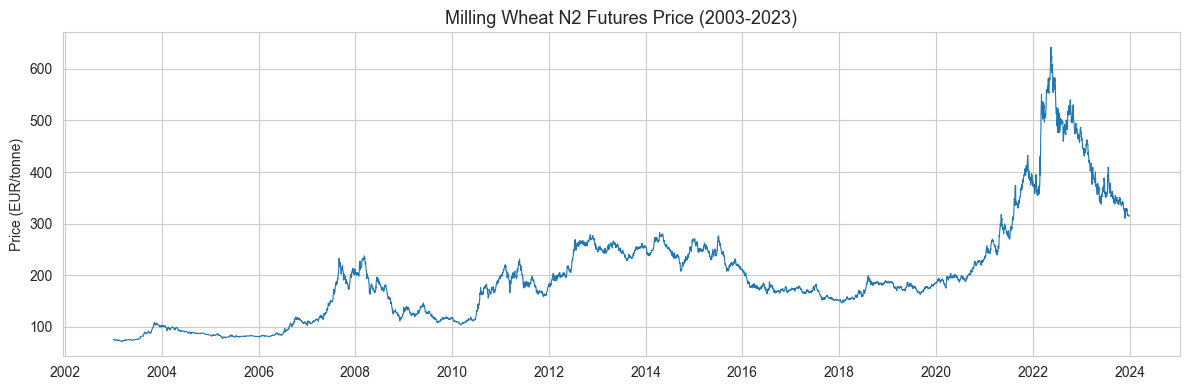

In [12]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(futures['Date'], futures['Price'], linewidth=0.8)
ax.set_title('Milling Wheat N2 Futures Price (2003-2023)', fontsize=13)
ax.set_ylabel('Price (EUR/tonne)')
ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tight_layout()
plt.show()

In [13]:
# ============================================================
# Target: continuous 5-day forward return (regression)
# ============================================================
futures['Fwd_Return'] = futures['Price'].shift(-FORECAST_HORIZON) / futures['Price'] - 1

# ============================================================
# MINIMAL price features: returns + volume only
#
# We deliberately strip price features to the bare minimum.
# The goal is to isolate whether AGRICULTURAL data from
# CY-Bench adds predictive signal, not to build the best
# possible price-based model. If we included RSI, SMAs,
# Bollinger bands etc., any lift from ag features could be
# confounded with price feature interactions.
#
# We keep only:
#   - ret_5d: 1-week momentum (same horizon as target)
#   - ret_20d: 1-month momentum (medium-term trend)
#   - vol_sma_ratio: relative volume (liquidity/attention)
#
# These 3 features form a minimal "market state" control.
# ============================================================

futures['ret_5d'] = futures['Price'].pct_change(5)
futures['ret_20d'] = futures['Price'].pct_change(20)
futures['vol_sma_ratio'] = futures['Volume'] / futures['Volume'].rolling(20).mean()

price_feature_cols = ['ret_5d', 'ret_20d', 'vol_sma_ratio']
print(f"Price features ({len(price_feature_cols)}): {price_feature_cols}")

Price features (3): ['ret_5d', 'ret_20d', 'vol_sma_ratio']


In [14]:
# ============================================================
# Generic CY-Bench loader for any country
# ============================================================

def load_cybench_csv(directory, pattern):
    matches = glob.glob(os.path.join(directory, pattern))
    if not matches:
        return None
    df = pd.read_csv(matches[0])
    return df

def load_country_data(country_code, cybench_dir):
    """
    Load all CY-Bench CSVs for a given country code.
    Returns dict of DataFrames keyed by data type.
    """
    possible = [
        os.path.join(cybench_dir, country_code),
        os.path.join(cybench_dir, 'EU'),
        cybench_dir,
    ]
    data_dir = None
    for p in possible:
        if os.path.isdir(p):
            pattern = f'meteo_wheat_{country_code}.csv'
            if glob.glob(os.path.join(p, pattern)):
                data_dir = p
                break

    if data_dir is None:
        print(f"  {country_code}: Data not found, skipping.")
        return None

    print(f"  {country_code}: Loading from {data_dir}")
    datasets = {}
    for var, pat in [('meteo', f'meteo_wheat_{country_code}.csv'),
                     ('soil_moisture', f'soil_moisture_wheat_{country_code}.csv'),
                     ('ndvi', f'ndvi_wheat_{country_code}.csv'),
                     ('fpar', f'fpar_wheat_{country_code}.csv')]:
        df = load_cybench_csv(data_dir, pat)
        if df is not None:
            # Filter to country regions
            if 'adm_id' in df.columns:
                df = df[df['adm_id'].astype(str).str.startswith(country_code)].copy()
            datasets[var] = df
            print(f"    {var}: {df.shape}, {df['adm_id'].nunique()} regions")

    # Load yield data for production weights
    yield_df = load_cybench_csv(data_dir, f'yield_wheat_{country_code}.csv')
    if yield_df is not None and 'adm_id' in yield_df.columns:
        yield_df = yield_df[yield_df['adm_id'].astype(str).str.startswith(country_code)].copy()
        datasets['yield'] = yield_df
        print(f"    yield: {yield_df.shape}, {yield_df['adm_id'].nunique()} regions")

    return datasets

# Load all three countries
print("Loading CY-Bench agricultural data\n")
country_data = {}

# France, Germany and Poland
countries = ['FR', 'DE', 'PL']

for country in countries:
    data = load_country_data(country, CYBENCH_DATA_DIR)
    if data is not None:
        country_data[country] = data
    print()

print(f"Countries loaded: {list(country_data.keys())}")
for country, data in country_data.items():
    n_regions = set()
    for k, df in data.items():
        if 'adm_id' in df.columns:
            n_regions.update(df['adm_id'].unique())
    print(f"  {country}: {len(n_regions)} unique regions, data types: {list(data.keys())}")

Loading CY-Bench agricultural data

  FR: Loading from cy-bench\FR
    meteo: (814800, 11), 97 regions
    soil_moisture: (740886, 5), 97 regions
    ndvi: (97951, 4), 97 regions
    fpar: (80316, 4), 97 regions
    yield: (2571, 7), 95 regions

  DE: Loading from cy-bench\DE
    meteo: (3368400, 11), 401 regions
    soil_moisture: (3055200, 5), 400 regions
    ndvi: (350540, 4), 401 regions
    fpar: (332028, 4), 401 regions
    yield: (15233, 12), 397 regions

  PL: Loading from cy-bench\PL
    meteo: (142800, 11), 17 regions
    soil_moisture: (129846, 5), 17 regions
    ndvi: (16115, 4), 17 regions
    fpar: (14076, 4), 17 regions
    yield: (301, 7), 17 regions

Countries loaded: ['FR', 'DE', 'PL']
  FR: 98 unique regions, data types: ['meteo', 'soil_moisture', 'ndvi', 'fpar', 'yield']
  DE: 401 unique regions, data types: ['meteo', 'soil_moisture', 'ndvi', 'fpar', 'yield']
  PL: 17 unique regions, data types: ['meteo', 'soil_moisture', 'ndvi', 'fpar', 'yield']


The following cells execute the computationally expensive data loading, production weight calculation, and feature engineering pipeline. Outputs are preserved from previous execution.

In [20]:
# ============================================================
# Step 4a: Build production weights per region
#
# Production weights serve TWO purposes:
#   1. Aggregating per-region predictions to EU level
#      (Paudel et al. 2022, Section 2.5.3)
#   2. Informing which regions matter economically
#
# We use PREVIOUS year's production to avoid look-ahead bias.
#
# HANDLING INCOMPLETE DATA (Germany):
#   Germany's CY-Bench data has:
#     - yield:        available every year
#     - harvest_area: available only every ~4 years (census)
#     - production:   entirely NaN
#   France/Poland have all three columns filled.
#
#   Solution (following user specification):
#     1. Forward-fill harvest_area within each region
#        (area changes slowly between censuses)
#     2. Compute production = yield * harvest_area
#   This is standard practice: Eurostat publishes area data
#   less frequently than yield, and interpolation/carry-forward
#   is the norm in operational systems (Cerrani & López Lozano,
#   2017).
#
# HANDLING SHORT TIME SERIES:
#   Some regions stop reporting before 2023 (e.g., France stops
#   at 2020, some German regions earlier). We use the most
#   recent available production as fallback.
# ============================================================

production_weights = {}  # {adm_id: {year: production_tonnes}}

for cc, data in country_data.items():
    if 'yield' not in data:
        continue
    ydf = data['yield'].copy()

    # Ensure columns exist
    if 'yield' not in ydf.columns:
        continue

    # --- Handle missing harvest_area and production ---
    # Check which area column exists (FR uses 'harvest_area', DE also)
    area_col = None
    for candidate in ['harvest_area', 'planted_area']:
        if candidate in ydf.columns:
            area_col = candidate
            break

    if area_col is not None:
        # Forward-fill harvest_area within each region
        # (area changes slowly; census every ~4 years for DE)
        ydf = ydf.sort_values(['adm_id', 'harvest_year'])
        ydf[area_col] = ydf.groupby('adm_id')[area_col].ffill()
        # Also backward-fill to cover years before first census
        ydf[area_col] = ydf.groupby('adm_id')[area_col].bfill()

    # Compute production where missing
    if 'production' not in ydf.columns:
        ydf['production'] = np.nan

    missing_prod = ydf['production'].isna()
    if missing_prod.any() and area_col is not None:
        ydf.loc[missing_prod, 'production'] = (
            ydf.loc[missing_prod, 'yield'] * ydf.loc[missing_prod, area_col]
        )
        n_filled = missing_prod.sum() - ydf['production'].isna().sum()
        print(f"  {cc}: Filled {n_filled} missing production values "
              f"(yield * forward-filled {area_col})")

    # Remaining NaN in production (no area data at all)
    still_missing = ydf['production'].isna().sum()
    if still_missing > 0:
        print(f"  {cc}: {still_missing} rows still missing production "
              f"(no area data available)")

    # Build the weights dictionary
    for _, row in ydf.iterrows():
        adm = row['adm_id']
        yr = row['harvest_year']
        prod = row['production']
        if pd.notna(prod) and prod > 0:
            if adm not in production_weights:
                production_weights[adm] = {}
            production_weights[adm][yr] = prod

    n_regions = len([r for r in production_weights if r.startswith(cc)])
    print(f"  {cc}: {n_regions} regions with production weights")

print(f"\nTotal regions with production weights: {len(production_weights)}")
for cc in country_data:
    cc_regions = [r for r in production_weights if r.startswith(cc)]
    if cc_regions:
        # Show year coverage
        all_years = set()
        for r in cc_regions:
            all_years.update(production_weights[r].keys())
        print(f"  {cc}: {len(cc_regions)} regions, "
              f"years {min(all_years)}-{max(all_years)}")

# Helper: get production weight for a region in a given year
# Uses previous year's production (lag 1 year to avoid look-ahead)
def get_production_weight(adm_id, year):
    if adm_id not in production_weights:
        return 0.0
    prev_year = year - 1
    if prev_year in production_weights[adm_id]:
        return production_weights[adm_id][prev_year]
    # Fallback: use nearest earlier available year
    available = sorted(production_weights[adm_id].keys())
    earlier = [y for y in available if y < year]
    if earlier:
        return production_weights[adm_id][earlier[-1]]
    # Last resort: use earliest available
    if available:
        return production_weights[adm_id][available[0]]
    return 0.0

  FR: 95 regions with production weights
  DE: Filled 15223 missing production values (yield * forward-filled harvest_area)
  DE: 10 rows still missing production (no area data available)
  DE: 396 regions with production weights
  PL: 17 regions with production weights

Total regions with production weights: 508
  FR: 95 regions, years 1989-2020
  DE: 396 regions, years 1979-2021
  PL: 17 regions, years 2003-2020


In [10]:
# ============================================================
# Step 4b: Process time-series data PER REGION
#
# For each region, we:
#   1. Parse dates
#   2. Combine all data types (meteo, soil, ndvi, fpar)
#   3. Forward-fill to daily frequency
#   4. Store as {adm_id: DataFrame}
#
# NO cross-regional aggregation at this stage.
# ============================================================

def process_region_timeseries(df, name):
    """Parse dates and identify variable columns."""
    if df is None or df.empty:
        return None
    df = df.copy()
    meta_cols = {'adm_id', 'crop_name', 'country_code', 'date',
                 'harvest_year', 'yield', 'harvest_area', 'production',
                 'sos', 'eos', 'crop_area', 'crop_area_percentage',
                 'region_area', 'geometry'}
    var_cols = [c for c in df.columns if c not in meta_cols]
    if 'date' not in df.columns:
        return None
    df['date'] = pd.to_datetime(df['date'], format='%Y%m%d', errors='coerce')
    df = df.dropna(subset=['date'])
    for c in var_cols:
        df[c] = pd.to_numeric(df[c], errors='coerce')
    return df[['adm_id', 'date'] + var_cols], var_cols

def build_region_daily(datasets, country_code):
    """
    Build per-region daily DataFrames from CY-Bench data.
    Returns dict: {adm_id: DataFrame with date + variable columns}
    """
    # Process each data type
    processed = {}
    for dtype in ['meteo', 'soil_moisture', 'ndvi', 'fpar']:
        if dtype not in datasets:
            continue
        result = process_region_timeseries(datasets[dtype], f"{country_code}_{dtype}")
        if result is not None:
            df, var_cols = result
            # Prefix variable names with dtype
            rename = {c: f'{dtype}_{c}' for c in var_cols}
            df = df.rename(columns=rename)
            processed[dtype] = df

    if not processed:
        return {}

    # Get all regions across data types
    all_regions = set()
    for df in processed.values():
        all_regions.update(df['adm_id'].unique())

    # Build per-region combined DataFrames
    region_dfs = {}
    for region in sorted(all_regions):
        dfs_for_region = []
        for dtype, df in processed.items():
            rdf = df[df['adm_id'] == region].drop(columns=['adm_id']).copy()
            if len(rdf) == 0:
                continue
            rdf = rdf.sort_values('date')
            dfs_for_region.append(rdf)

        if not dfs_for_region:
            continue

        # Merge all data types on date
        combined = dfs_for_region[0]
        for df in dfs_for_region[1:]:
            combined = combined.merge(df, on='date', how='outer')
        combined = combined.sort_values('date')

        # Expand to daily with LOCF
        full_dates = pd.date_range(combined['date'].min(),
                                    combined['date'].max(), freq='D')
        combined = combined.set_index('date').reindex(full_dates).ffill()
        combined = combined.reset_index().rename(columns={'index': 'date'})

        region_dfs[region] = combined

    return region_dfs


# Build per-region daily data for all countries
print("Building per-region daily datasets...\n")
all_region_dfs = {}  # {adm_id: DataFrame}

for cc, data in country_data.items():
    region_dfs = build_region_daily(data, cc)
    all_region_dfs.update(region_dfs)
    print(f"  {cc}: {len(region_dfs)} regions processed")
    if region_dfs:
        sample_region = list(region_dfs.keys())[0]
        sample_df = region_dfs[sample_region]
        n_feats = len([c for c in sample_df.columns if c != 'date'])
        print(f"    Sample region {sample_region}: {sample_df.shape[0]} days, "
              f"{n_feats} features")
        print(f"    Date range: {sample_df['date'].min().date()} to "
              f"{sample_df['date'].max().date()}")

print(f"\nTotal regions across all countries: {len(all_region_dfs)}")

Building per-region daily datasets...

  FR: 97 regions processed
    Sample region FR102: 8400 days, 12 features
    Date range: 2001-01-01 to 2023-12-31


KeyboardInterrupt: 

In [11]:
# ============================================================
# Step 4c: Save per-region daily DataFrames to CSV
# ============================================================
import os

REGION_DATA_DIR = "region_daily_data"
os.makedirs(REGION_DATA_DIR, exist_ok=True)

# Build index and save each region
index_rows = []
for cc, data in country_data.items():
    region_dfs = build_region_daily(data, cc)
    for adm_id, df in region_dfs.items():
        # Save region CSV
        path = os.path.join(REGION_DATA_DIR, f"{adm_id}_daily.csv")
        df.to_csv(path, index=False)
        index_rows.append({'adm_id': adm_id, 'country': cc})

# Save region index
index_df = pd.DataFrame(index_rows)
index_path = os.path.join(REGION_DATA_DIR, "_region_index.csv")
index_df.to_csv(index_path, index=False)

print(f"Saved {len(index_rows)} regions to '{REGION_DATA_DIR}/'")
print(f"Region index saved to '{index_path}'")

KeyboardInterrupt: 

In [8]:
# ============================================================
# Load pre-generated per-region daily CSVs
#
# Skips: CY-Bench loading, parsing, daily expansion, saving
# Requires: the region_daily_data/ folder from a previous run
# Only loads regions from countries in the countries list.
# ============================================================

REGION_DATA_DIR = "region_daily_data"

# --- Load region index ---
index_path = os.path.join(REGION_DATA_DIR, "_region_index.csv")
region_index = pd.read_csv(index_path)
print(f"Found {len(region_index)} total regions in '{REGION_DATA_DIR}/'")

# --- Filter to countries list ---
region_index = region_index[region_index['country'].isin(countries)]
print(f"After filtering to {countries}: {len(region_index)} regions")

# --- Load region CSVs into all_region_dfs ---
all_region_dfs = {}
for _, row in region_index.iterrows():
    adm_id = row['adm_id']
    path = os.path.join(REGION_DATA_DIR, f"{adm_id}_daily.csv")
    df = pd.read_csv(path, parse_dates=['date'])
    all_region_dfs[adm_id] = df

print(f"Loaded {len(all_region_dfs)} regions")
print(f"countries: {region_index.groupby('country')['adm_id'].count().to_dict()}")

Found 659 total regions in 'region_daily_data/'
After filtering to ['FR', 'DE', 'PL']: 515 regions
Loaded 515 regions
countries: {'DE': 401, 'FR': 97, 'PL': 17}


In [9]:
# ============================================================
# Per-region feature engineering
#
# For each region's daily DataFrame, we compute:
#   1. Rolling means and cumulative sums (30d, 60d windows)
#   2. Threshold-based stress indicators (CY-Bench: cold/hot/dry days)
#   3. NDVI/fPAR anomalies (relative to expanding DOY climatology)
#   4. Phenological phase indicators (based on month)
#   5. Cross-variable interactions (VPD stress, DTR)
#
# CY-Bench Section 2.2.3: "Following expert recommendations we create
# monthly averages... cumulative growing degree days, cumulative
# precipitation, cumulative fPAR and cumulative NDVI... number of days
# in which tmin < 0 ('cold days'), tmax > 35 ('hot days'), prec < 1mm
# ('dry days')."
# ============================================================

def engineer_region_features(df):
    """
    Apply feature engineering to a single region's daily DataFrame.
    Input: DataFrame with 'date' column and raw CY-Bench variables.
    Output: DataFrame with original + engineered features.
    """
    df = df.copy().sort_values('date').set_index('date')
    month = df.index.month

    # --- Spring heat shock (Mar-May): days > 25°C ---
    if 'meteo_tmax' in df.columns:
        spring_heat = ((month >= 3) & (month <= 5)).astype(float) * (df['meteo_tmax'] > 25).astype(float)
        df['spring_heat_days_30d'] = spring_heat.rolling(30, min_periods=5).sum()
        df['spring_heat_days_60d'] = spring_heat.rolling(60, min_periods=5).sum()

    # --- Grain-fill heat stress (May-Jul): days > 30°C ---
    # Schlenker & Roberts (2009): nonlinear temperature effects
    # indicate severe damages to US crop yields
    if 'meteo_tmax' in df.columns:
        gf_heat = ((month >= 5) & (month <= 7)).astype(float) * (df['meteo_tmax'] > 30).astype(float)
        df['grainfill_heat_days_30d'] = gf_heat.rolling(30, min_periods=5).sum()
        # Cumulative excess heat above 30°C during grain fill
        gf_excess = ((month >= 5) & (month <= 7)).astype(float) * (df['meteo_tmax'] - 30).clip(lower=0)
        df['grainfill_excess_heat_30d'] = gf_excess.rolling(30, min_periods=5).sum()

    # --- CY-Bench threshold indicators (Paudel et al. 2025, §2.2.3) ---
    # "number of days tmin < 0°C ('cold days'), tmax > 35°C ('hot days'),
    #  prec < 1mm ('dry days')"
    if 'meteo_tmin' in df.columns:
        df['cold_days_30d'] = (df['meteo_tmin'] < 0).astype(float).rolling(30, min_periods=5).sum()
    if 'meteo_tmax' in df.columns:
        df['hot_days_30d'] = (df['meteo_tmax'] > 35).astype(float).rolling(30, min_periods=5).sum()
    if 'meteo_prec' in df.columns:
        df['dry_days_30d'] = (df['meteo_prec'] < 1).astype(float).rolling(30, min_periods=5).sum()

    # ============================================================
    # C. NDVI ANOMALY - "crop health surprise"
    # How does current NDVI compare to what's normal for this
    # time of year? Low NDVI in Jan = normal (dormant).
    # Low NDVI in May = disaster. We compute the anomaly
    # relative to the historical day-of-year mean.
    # Expanding climatology avoids future leakage.
    # ============================================================
    if 'fpar_fpar' in df.columns:
        df['fpar_doy'] = df.index.dayofyear
        fpar_clim = df.groupby('fpar_doy')['fpar_fpar'].expanding().mean()
        fpar_clim = fpar_clim.reset_index(level=0, drop=True).sort_index()
        df['fpar_anomaly'] = df['fpar_fpar'] - fpar_clim
        df['fpar_anomaly_30d'] = df['fpar_anomaly'].rolling(30, min_periods=5).mean()
        df = df.drop(columns=['fpar_doy'])

    # ============================================================
    # E. WEEKEND WEATHER ACCUMULATOR
    # Futures don't trade Sat/Sun but weather happens. On Monday,
    # the market reacts to 3 days of news (Fri evening + weekend).
    # ============================================================
    df['is_monday'] = (df.index.dayofweek == 0).astype(float)
    if 'meteo_prec' in df.columns:
        df['weekend_prec'] = df['meteo_prec'].rolling(3, min_periods=1).sum() * df['is_monday']
    if 'meteo_tmax' in df.columns:
        df['weekend_tmax'] = df['meteo_tmax'].rolling(3, min_periods=1).max() * df['is_monday']
    if 'meteo_tmin' in df.columns:
        df['weekend_tmin'] = df['meteo_tmin'].rolling(3, min_periods=1).min() * df['is_monday']

    # ============================================================
    # F. STANDARDISED PRECIPITATION INDEX (SPI-like)
    # Z-score of rolling precipitation relative to its expanding
    # historical distribution. Positive = wetter than normal,
    # negative = drought.
    # (McKee et al., 1993; widely used in drought monitoring)
    # ============================================================
    if 'meteo_prec' in df.columns:
        for window in [30, 60]:
            roll_prec = df['meteo_prec'].rolling(window, min_periods=10).sum()
            spi_mean = roll_prec.expanding(min_periods=60).mean()
            spi_std = roll_prec.expanding(min_periods=60).std()
            df[f'spi_{window}d'] = (roll_prec - spi_mean) / spi_std.replace(0, np.nan)

    # ============================================================
    # Clean up: drop intermediate masking columns
    # Phase indicators (dormant, stem_elong, flowering) are KEPT
    # as features - they tell the model which crop phase we're in.
    # Only is_monday is dropped (used only for weekend accumulator).
    # ============================================================
    df = df.drop(columns=['is_monday'], errors='ignore')
    df = df.reset_index()

    return df


# Apply to all regions
print("Applying feature engineering to all regions...\n")
n_before = {}
for adm_id, df in all_region_dfs.items():
    n_before[adm_id] = len([c for c in df.columns if c != 'date'])
    all_region_dfs[adm_id] = engineer_region_features(df)

# Report
sample = list(all_region_dfs.keys())[0]
n_after = len([c for c in all_region_dfs[sample].columns if c != 'date'])
print(f"Feature engineering complete for {len(all_region_dfs)} regions")
print(f"  Before: ~{n_before[sample]} features per region")
print(f"  After:  ~{n_after} features per region (+{n_after - n_before[sample]} engineered)")

Applying feature engineering to all regions...

Feature engineering complete for 515 regions
  Before: ~12 features per region
  After:  ~26 features per region (+14 engineered)


---

## 4. Spatial Aggregation: Clustering vs. Per-Region Models (Goodfellow et al. §11.2)

### 4.1 The Dimensionality Problem

With 515 regions and 76 features per region, the raw feature matrix contains 39,140 columns - far exceeding the 5,364 observations. Goodfellow et al. (§11.2) advise choosing model complexity relative to data size: "unless your training set contains tens of millions of examples or more, you should include some mild forms of regularization from the start" (p. 420).

We implement two approaches to this problem. The first approach (Approach A) clusters regions into agro-climatic zones and aggregates features within each cluster, producing a wide matrix of ~450 features. The second approach (Approach B) fits a separate lightweight model per region and aggregates the 515 predictions using production weights. Paudel et al. (2022) demonstrated that regional models outperform nationally aggregated models for crop yield prediction, motivating this comparison.

### 4.2 Feature Correlation Matrix

Processing correlation matrices for 515 regions...
Total unique features found across all regions: 26


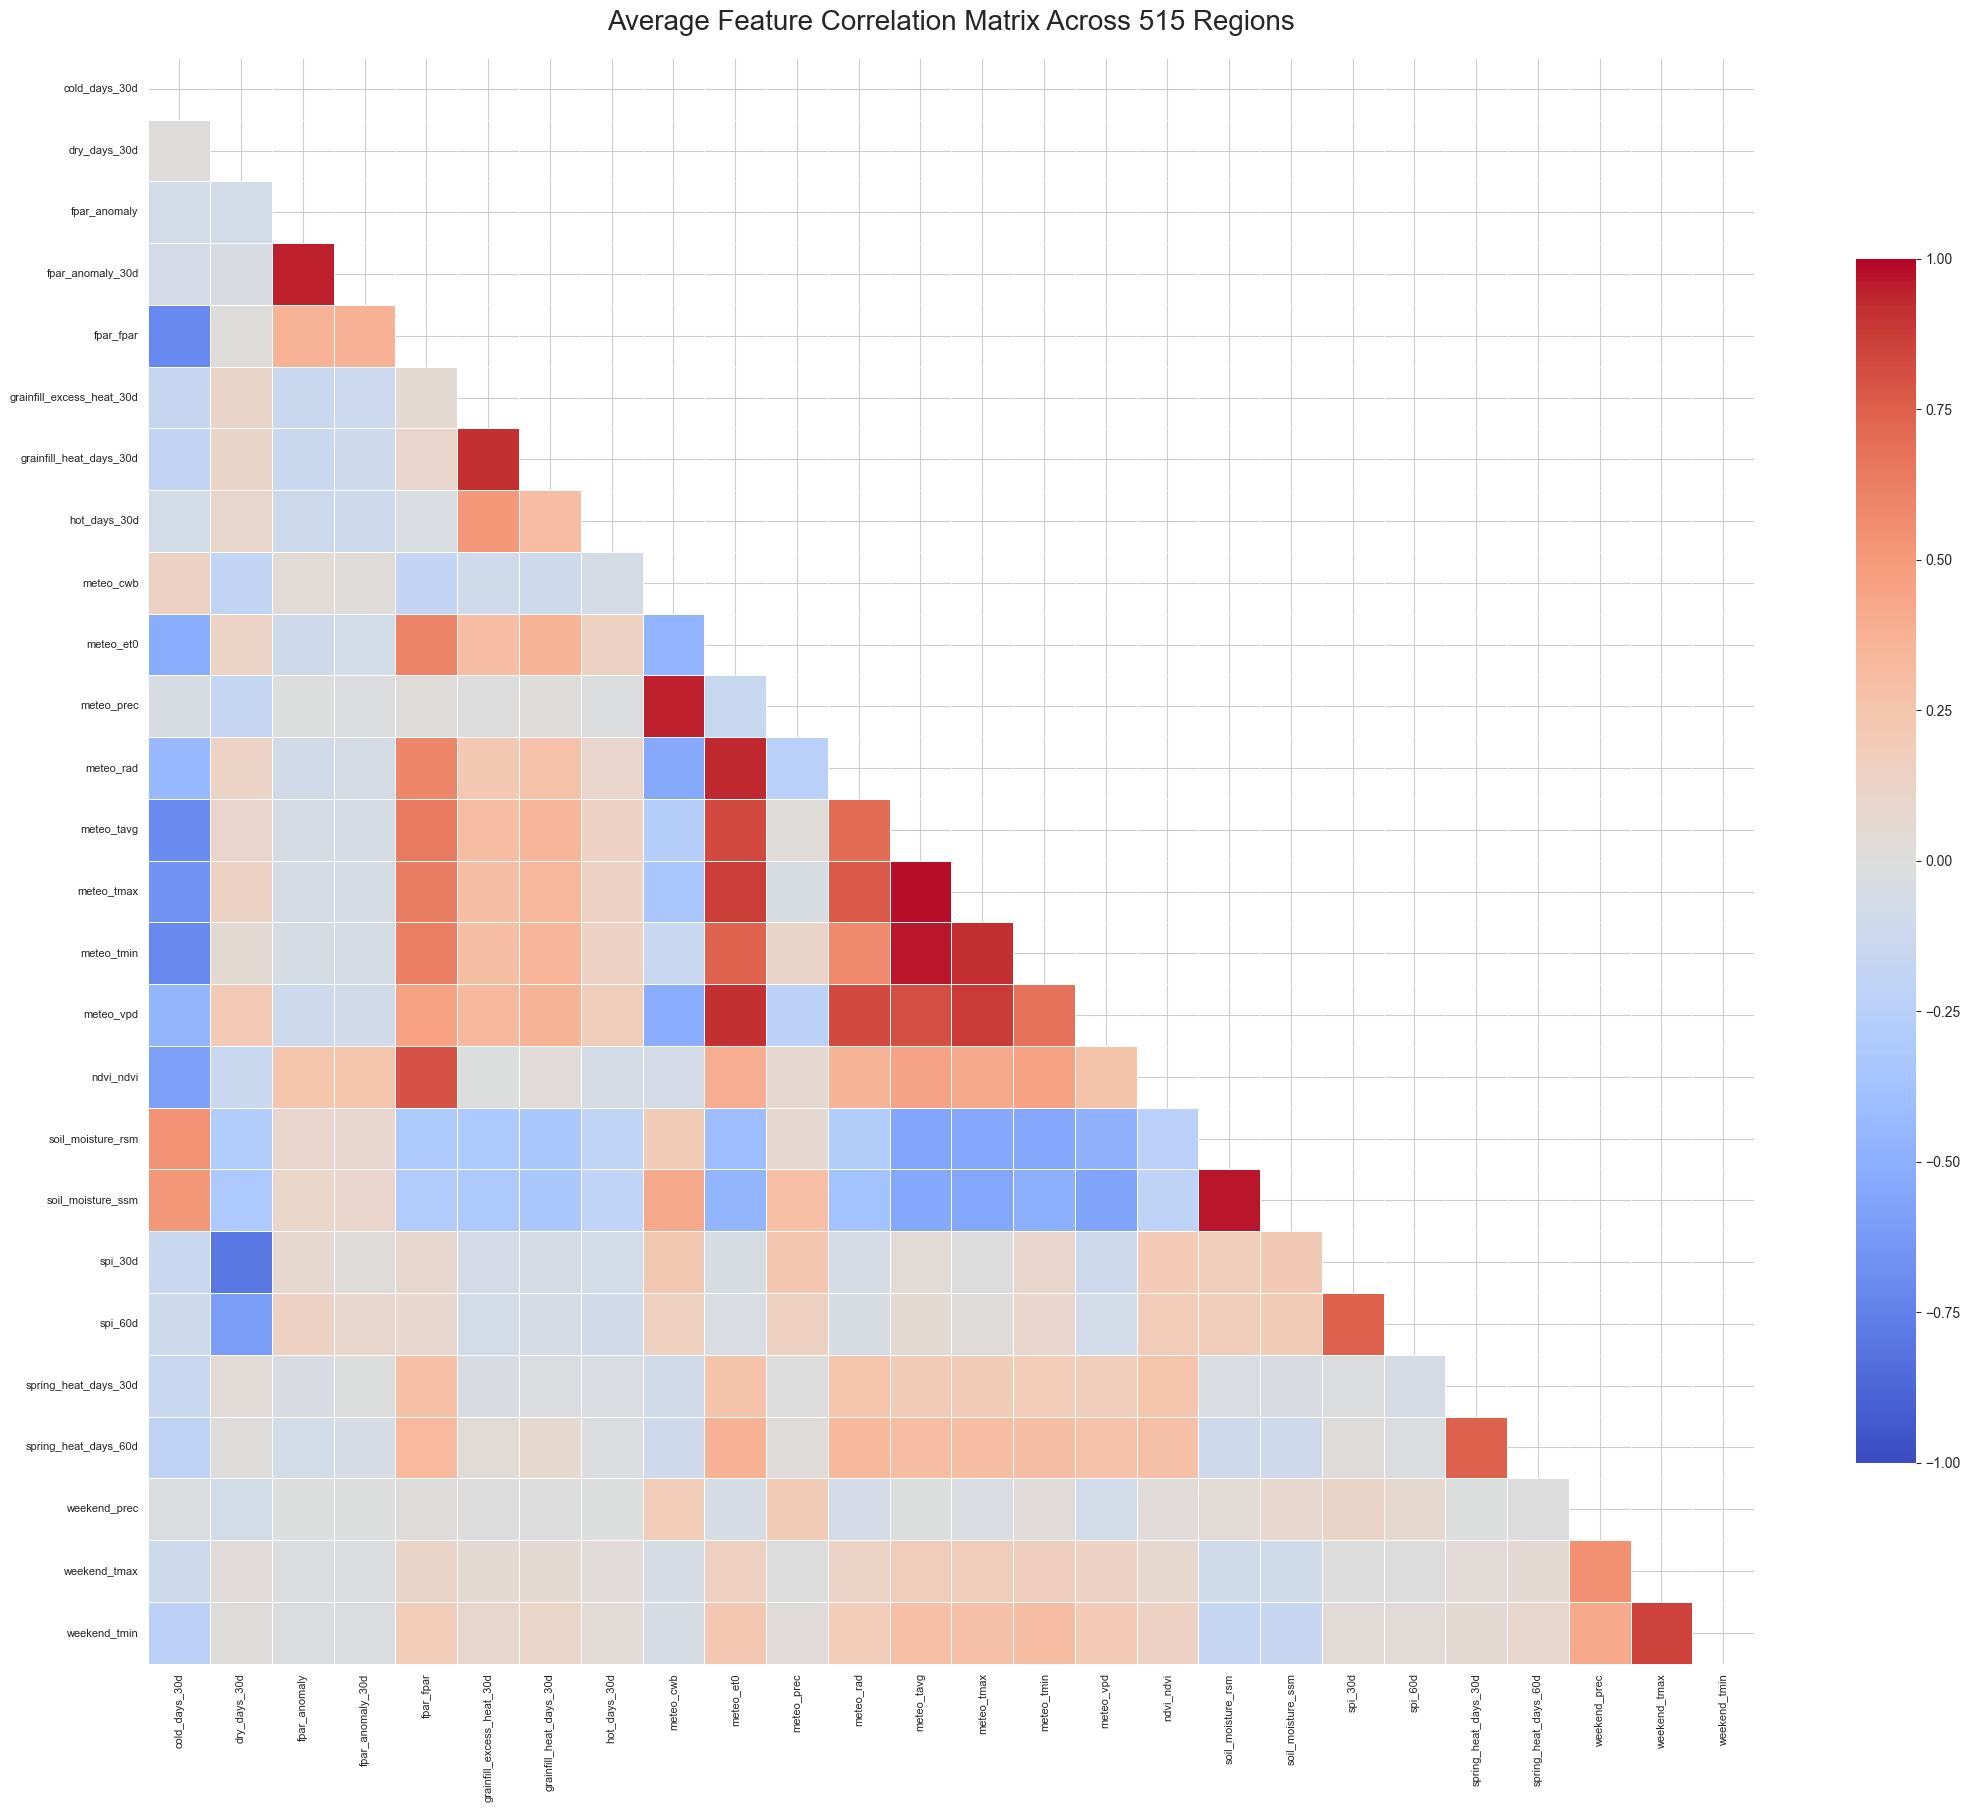

In [10]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def compute_average_correlation(region_dfs_dict):
    """
    Computes an average correlation matrix across multiple regions,
    handling missing features dynamically via reindexing.
    """
    fisher_z_matrices = []
    
    print(f"Processing correlation matrices for {len(region_dfs_dict)} regions...")
    
    # ------------------------------------------------------------
    # FIX STEP 1: Find the master list of all unique features
    # ------------------------------------------------------------
    master_features = set()
    for df in region_dfs_dict.values():
        cols = df.drop(columns=['date'], errors='ignore').select_dtypes(include=[np.number]).columns
        master_features.update(cols)
        
    master_features = sorted(list(master_features))
    print(f"Total unique features found across all regions: {len(master_features)}")
    
    # ------------------------------------------------------------
    # FIX STEP 2: Standardize all matrices to the master shape
    # ------------------------------------------------------------
    for adm_id, df in region_dfs_dict.items():
        feat_df = df.drop(columns=['date'], errors='ignore').select_dtypes(include=[np.number])
        
        # Calculate raw correlation
        corr = feat_df.corr()
        
        # Force the matrix to be exactly the size of master_features
        # Missing columns/rows become NaN automatically
        corr = corr.reindex(index=master_features, columns=master_features)
        
        # Apply Fisher Z-transform
        corr_vals = corr.values
        # Clip values to avoid infinity from arctanh(1.0), keeping NaNs intact
        corr_clipped = np.where(np.isnan(corr_vals), np.nan, np.clip(corr_vals, -0.9999, 0.9999))
        fisher_z = np.arctanh(corr_clipped)
        
        fisher_z_matrices.append(fisher_z)

    # ------------------------------------------------------------
    # Calculate the mean and Inverse Fisher Transform
    # ------------------------------------------------------------
    # Suppress warnings if an entire slice is NaN (e.g., a feature with zero variance)
    with np.errstate(invalid='ignore'):
        avg_z_matrix = np.nanmean(fisher_z_matrices, axis=0)
    
    avg_corr_matrix = np.tanh(avg_z_matrix)
    
    # Return standard DataFrame
    avg_corr_df = pd.DataFrame(avg_corr_matrix, index=master_features, columns=master_features)
    
    return avg_corr_df

# ==========================================
# Execute the corrected function
# ==========================================
avg_correlation_matrix = compute_average_correlation(all_region_dfs)

# ==========================================
# Visualization: The Heatmap
# ==========================================
plt.figure(figsize=(22, 18))

mask = np.triu(np.ones_like(avg_correlation_matrix, dtype=bool))

sns.heatmap(avg_correlation_matrix, 
            mask=mask, 
            cmap='coolwarm', 
            center=0, 
            vmin=-1, 
            vmax=1, 
            annot=False, 
            square=True, 
            linewidths=.5, 
            cbar_kws={"shrink": .75})

plt.title(f"Average Feature Correlation Matrix Across {len(all_region_dfs)} Regions", fontsize=20, pad=20)
plt.xticks(fontsize=8, rotation=90)
plt.yticks(fontsize=8, rotation=0)
plt.tight_layout()
plt.show()

In [11]:
import pandas as pd
import numpy as np

def flag_highly_correlated_pairs(corr_matrix, threshold=0.85):
    """
    Scans a correlation matrix and returns a DataFrame of feature pairs 
    that exceed the absolute correlation threshold.
    """
    print(f"Scanning for feature pairs with absolute correlation > {threshold}...\n")
    
    # 1. Take the absolute value to catch both strong positive and negative correlations
    abs_corr = corr_matrix.abs()
    
    # 2. Mask the lower triangle and diagonal. 
    # This prevents flagging A-B and B-A as two separate issues, and ignores self-correlation (1.0).
    upper_tri = abs_corr.where(np.triu(np.ones(abs_corr.shape), k=1).astype(bool))
    
    # 3. Extract the problematic pairs
    collinear_pairs = []
    for column in upper_tri.columns:
        # Find rows in this column that exceed the threshold
        high_corr_indices = upper_tri[column][upper_tri[column] > threshold].index
        
        for index in high_corr_indices:
            # Grab the original correlation value (with its positive/negative sign)
            original_corr_val = corr_matrix.loc[index, column]
            collinear_pairs.append({
                'Feature 1': index,
                'Feature 2': column,
                'Correlation': original_corr_val
            })
            
    # 4. Format the output
    results_df = pd.DataFrame(collinear_pairs)
    
    if results_df.empty:
        print("No highly correlated features found at this threshold.")
        return results_df, []
        
    # Sort by the most aggressively correlated pairs first
    results_df['Abs_Corr'] = results_df['Correlation'].abs()
    results_df = results_df.sort_values(by='Abs_Corr', ascending=False).drop(columns=['Abs_Corr']).reset_index(drop=True)
    
    # 5. Generate a simple "hit list" of features you can immediately drop
    # By simply taking 'Feature 2' from the pairs, we keep one version of the feature and drop the redundant one.
    features_to_drop = list(set(results_df['Feature 2']))
    
    print(f"Found {len(results_df)} highly correlated pairs.")
    print(f"Suggesting to drop {len(features_to_drop)} redundant features.")
    
    return results_df, features_to_drop

# ==========================================
# Execute the function
# ==========================================
# Assuming avg_correlation_matrix is already generated from the previous step
collinear_df, drop_list = flag_highly_correlated_pairs(avg_correlation_matrix, threshold=0.85)

# View the worst offenders
print("\nTop 10 most correlated pairs:")
print(collinear_df.head(10))

# View the exact list of features to exclude from your model
print("\nSuggested features to drop:")
print(drop_list)

Scanning for feature pairs with absolute correlation > 0.85...

Found 12 highly correlated pairs.
Suggesting to drop 9 redundant features.

Top 10 most correlated pairs:
                   Feature 1                Feature 2  Correlation
0                 meteo_tavg               meteo_tmax     0.984035
1          soil_moisture_rsm        soil_moisture_ssm     0.967035
2                 meteo_tavg               meteo_tmin     0.965498
3                  meteo_cwb               meteo_prec     0.945466
4               fpar_anomaly         fpar_anomaly_30d     0.945453
5                  meteo_et0                meteo_rad     0.935771
6                 meteo_tmax               meteo_tmin     0.914879
7  grainfill_excess_heat_30d  grainfill_heat_days_30d     0.911427
8                  meteo_et0                meteo_vpd     0.908683
9                 meteo_tmax                meteo_vpd     0.878551

Suggested features to drop:
['meteo_prec', 'weekend_tmin', 'meteo_vpd', 'fpar_anomaly_30d', 

### 4.3 Per-Region Models

Rather than clustering, we fit one Ridge regression per region using only that region's 76 features plus 3 price features (79 total). This avoids information loss from averaging diverse regions. The 515 per-region predictions are aggregated using production weights. With only 79 features per model and ~5,000 observations, regularised linear models are well-conditioned.

In [12]:
# ============================================================
# 4.3 Per-region model infrastructure
# ============================================================
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.ensemble import ExtraTreesRegressor, RandomForestRegressor
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# Build per-region merged DataFrames using all_region_dfs (from cell 14/16)
futures_clean = futures.dropna(subset=['Fwd_Return'] + price_feature_cols).copy()
futures_sorted = futures_clean.sort_values('Date')

region_model_data = {}
for reg_id, rdf in all_region_dfs.items():
    ag_sorted = rdf.sort_values('date')
    merged = pd.merge_asof(futures_sorted, ag_sorted,
        left_on='Date', right_on='date', direction='backward')
    merged = merged.drop(columns=['date'], errors='ignore')
    ag_cols = [c for c in rdf.columns if c != 'date']
    for col in ag_cols:
        if col in merged.columns:
            merged[col] = merged[col].ffill().fillna(0)
    merged = merged.dropna(subset=['Fwd_Return'] + price_feature_cols)
    if len(merged) > 500:
        region_model_data[reg_id] = {
            'df': merged,
            'ag_cols': ag_cols,
            'all_cols': price_feature_cols + ag_cols,
        }

print(f'Regions with sufficient data: {len(region_model_data)} / {len(all_region_dfs)}')

Regions with sufficient data: 515 / 515


---

## 5. Default Baselines and Train-Test Diagnostics (Goodfellow et al. §11.2 + §11.3)

Our dataset spans harvest years 2003–2023, giving us 21 years of observations per region. We adopt a temporal split rather than a random one, since random partitioning would leak future climate and market conditions into the training set, which would result in data leakage. Thus, we divide the data into three chronological partitions: training (2003–2016), validation (2017–2019), and test (2020–2023). The training cutoff is placed after 2016 so the model learns from both the 2007–2008 global food price crisis (during which wheat prices rose by 136%) and the secondary price spike in 2010–2011, giving it exposure to volatile periods in recent agricultural history. This is consistent with the approach of [Paudel et al. (2022)](https://www.sciencedirect.com/science/article/pii/S0308521X20308775), who trained their machine learning baseline with data up to 2011 or 2012, with predictions extrapolating up to 2018, and with crop yield forecasting studies that commonly reserve the final years of the dataset for testing to reflect genuine forecasting conditions ([Gutiérrez-Avila et al., 2023](https://www.frontiersin.org/journals/plant-science/articles/10.3389/fpls.2023.1128388/full)). The three-year validation window (2017–2019) provides a relatively stable period for hyperparameter tuning and model selection. Finally, the test period (2020–2023) then provides a genuinely challenging out-of-sample evaluation, encompassing both COVID-19 supply chain disruptions and the 2022 Russia–Ukraine war, which caused wheat prices to surge to their highest levels since 2008. This results in an approximate 67/14/19 split is broadly consistent with the 60/20/20 ratio used in the [SustainBench](https://sustainlab-group.github.io/sustainbench/docs/datasets/sdg2/crop_yield.html) crop yield benchmark (which creates a 60-20-20 train-validation-test split for each of the three countries).

### 5.1 Model Selection and Validation Protocol

Our input is a fixed-size feature vector. Following Goodfellow et al. (p. 420), we use feedforward architectures. We start by using Ridge and Lasso, then move on to tree based ensemble methods ExtraTrees and RF and, finally, we fit a Feedforward NN.

As defined 

For tree-based and linear models, we use walk-forward validation with an expanding training window. For neural networks, we further split the training window: the last 20 per cent of training data serves as a validation set for early stopping and hyperparameter selection. The test year is never seen during training or model selection, preventing the data leakage that would occur if the test set were used for early stopping.

Following §11.3, we report both training and test R-squared. If training R-squared is low, the model underfits. If the train-test gap is large, the model overfits. If both are poor despite large capacity, the issue is data quality.

### 5.2 Walk Forward Function Definition

In [13]:
# ============================================================
# 5.2 Walk-forward with train/validation/test split
#
# Goodfellow §11.4: "tuning the parameters other than the
# learning rate requires monitoring both training and test error"
# (p. 424). We split data into three sets:
#   - Train: years < T-1 (fit parameters)
#   - Validation: year T-1 (tune hyperparameters / early stopping)
#   - Test: year T (final evaluation, never seen during training)
# ============================================================
from sklearn.metrics import r2_score, mean_squared_error, roc_auc_score

test_start_year = 2020
test_end_year = 2023

def walk_forward(df, feature_cols, model_class, model_kwargs,
                 test_start=test_start_year, test_end=test_end_year,
                 target_col='Fwd_Return', sample_weight_col=None):
    results = []
    for ty in range(test_start, test_end + 1):
        train = df[df['Date'].dt.year < ty]
        test = df[df['Date'].dt.year == ty]
        if len(train) < 300 or len(test) < 20: continue
        
        sc = StandardScaler()
        X_tr = sc.fit_transform(train[feature_cols].values)
        X_te = sc.transform(test[feature_cols].values)
        y_tr = train[target_col].values
        y_te = test[target_col].values
        
        m = model_class(**dict(model_kwargs))
        if sample_weight_col and sample_weight_col in train.columns:
            m.fit(X_tr, y_tr, sample_weight=train[sample_weight_col].values)
        else:
            m.fit(X_tr, y_tr)
        
        yp_tr = m.predict(X_tr)
        yp_te = m.predict(X_te)
        
        results.append({
            'year': ty,
            'r2_train': r2_score(y_tr, yp_tr),
            'r2_test': r2_score(y_te, yp_te),
            'rmse_test': np.sqrt(mean_squared_error(y_te, yp_te)),
            'dir_test': np.mean(np.sign(yp_te) == np.sign(y_te)),
            'n_train': len(train), 'n_test': len(test),
        })
    
    if not results: return None
    r2_tr = np.mean([r['r2_train'] for r in results])
    r2_te = np.mean([r['r2_test'] for r in results])
    return {
        'r2_train': r2_tr, 'r2_test': r2_te, 'gap': r2_tr - r2_te,
        'rmse': np.mean([r['rmse_test'] for r in results]),
        'dir': np.mean([r['dir_test'] for r in results]),
        'per_year': results
    }

print('Walk-forward function defined.')

Walk-forward function defined.


### 5.3 Per-Region Models

Rather than clustering, we fit one model per region using only that region's features plus price features. Linear models (Ridge, Lasso) are tested across all 515 regions because they are computationally trivial. For ensemble methods, we test a lightweight configuration (100 estimators) because fitting 515 regions × 7 test years = 3,605 models per method would otherwise be prohibitively slow.

The per-region predictions are aggregated via production-weighted averaging across regions. Paudel et al. (2022) demonstrated that regional models outperform nationally aggregated ones for crop yield prediction, motivating this comparison.

#### 5.3.1 Defining Hyperparameter Tuning Grids and Functions

In [14]:
from sklearn.model_selection import ParameterSampler
from scipy.stats import uniform, randint, loguniform
import time as timer

# ============================================================
# Hyperparameter grids for each model
# ============================================================
PARAM_DISTRIBUTIONS = {
    'Ridge': {
        'model_cls': Ridge,
        'params': {
            'alpha': loguniform(0.01, 100),  # 0.01 to 100
        }
    },
    'Lasso': {
        'model_cls': Lasso,
        'params': {
            'alpha': loguniform(1e-5, 0.1),  # 1e-5 to 0.1
            'max_iter': [10000],
        }
    },
    'RF': {
        'model_cls': RandomForestRegressor,
        'params': {
            'n_estimators': [200,500],
            'max_depth': [3, 5, 8],
            'min_samples_leaf': [10, 20, 40],
            'max_features': ['sqrt', 'log2', 0.3, 0.5],
            'random_state': [42],
            'n_jobs': [-1],
        }
    },
    'ExtraTrees': {
        'model_cls': ExtraTreesRegressor,
        'params': {
            'n_estimators': [500],
            'max_depth': [3, 5, 8],
            'min_samples_leaf': [10, 20, 40],
            'max_features': ['sqrt', 'log2', 0.3, 0.5],
            'random_state': [42],
            'n_jobs': [-1],
        }
    },
}


In [15]:
# ============================================================
# Core evaluation function (production-weighted, walk-forward)
# ============================================================
def evaluate_params(model_cls, model_kw, region_model_data,
                    val_start_year, val_end_year, feature_key='ag_cols'):
    """
    Walk-forward evaluation over the VALIDATION period only.
    Returns dict with r2, dir_acc, rmse, mae or None if insufficient data.
    """
    all_y_true, all_y_pred = [], []

    for ty in range(val_start_year, val_end_year + 1):
        preds_this_year = []
        for reg_id, rdata in region_model_data.items():
            df = rdata['df']
            train = df[df['Date'].dt.year < ty]
            test = df[df['Date'].dt.year == ty]
            if len(train) < 300 or len(test) < 20:
                continue

            sc = StandardScaler()
            X_tr = sc.fit_transform(train[rdata[feature_key]].values)
            X_te = sc.transform(test[rdata[feature_key]].values)

            m = model_cls(**model_kw)
            m.fit(X_tr, train['Fwd_Return'].values)

            preds_this_year.append({
                'preds': m.predict(X_te),
                'dates': test['Date'].values,
                'y_true': test['Fwd_Return'].values,
                'weight': get_production_weight(reg_id, ty),
            })

        if not preds_this_year:
            continue

        n = len(preds_this_year[0]['dates'])
        agg = np.zeros(n)
        total_weight = 0.0
        for p in preds_this_year:
            if len(p['preds']) == n:
                w = p['weight']
                agg += p['preds'] * w
                total_weight += w

        if total_weight > 0:
            all_y_true.extend(preds_this_year[0]['y_true'])
            all_y_pred.extend(agg / total_weight)
        else:
            cnt = sum(1 for p in preds_this_year if len(p['preds']) == n)
            if cnt > 0:
                agg_eq = np.zeros(n)
                for p in preds_this_year:
                    if len(p['preds']) == n:
                        agg_eq += p['preds']
                all_y_true.extend(preds_this_year[0]['y_true'])
                all_y_pred.extend(agg_eq / cnt)

    if len(all_y_true) < 20:
        return None

    yt = np.array(all_y_true)
    yp = np.array(all_y_pred)
    return {
        'r2': r2_score(yt, yp),
        'dir_acc': np.mean(np.sign(yt) == np.sign(yp)),
        'rmse': np.sqrt(np.mean((yt - yp) ** 2)),
        'mae': np.mean(np.abs(yt - yp)),
    }


In [16]:
# ============================================================
# Randomised grid search
# ============================================================
def randomised_search(model_names, region_model_data,
                      val_start_year, val_end_year,
                      n_iter=20, feature_key='ag_cols',
                      scoring='r2', random_state=42):
    """
    Randomised hyperparameter search over the VALIDATION set.

    Parameters
    ----------
    model_names : list of str
        Which models to tune (keys of PARAM_DISTRIBUTIONS).
    val_start_year, val_end_year : int
        Validation period (NOT the final test set).
    n_iter : int
        Number of random parameter combinations per model.
    feature_key : str
        Key in region_model_data for feature columns.
    scoring : str
        Metric to optimise ('r2', 'dir_acc', 'rmse', 'mae').
        For rmse/mae, lower is better; for r2/dir_acc, higher is better.

    Returns
    -------
    best_params : dict  {model_name: {'params': {...}, 'score': float, ...}}
    all_results : dict  {model_name: list of trial dicts}
    """
    higher_is_better = scoring in ('r2', 'dir_acc')
    best_params = {}
    all_results = {}

    for model_name in model_names:
        if model_name not in PARAM_DISTRIBUTIONS:
            print(f"  Skipping {model_name}: not in PARAM_DISTRIBUTIONS")
            continue

        config = PARAM_DISTRIBUTIONS[model_name]
        model_cls = config['model_cls']
        sampler = list(ParameterSampler(
            config['params'], n_iter=n_iter, random_state=random_state
        ))

        print(f"\n{'='*60}")
        print(f"  {model_name}: testing {len(sampler)} combinations")
        print(f"  Validation period: {val_start_year}-{val_end_year}")
        print(f"{'='*60}")

        trials = []
        best_score = -np.inf if higher_is_better else np.inf
        best_trial = None

        for i, params in enumerate(sampler):
            t0 = timer.time()
            result = evaluate_params(
                model_cls, params, region_model_data,
                val_start_year, val_end_year, feature_key
            )
            elapsed = timer.time() - t0

            if result is None:
                print(f"  [{i+1:3d}/{len(sampler)}] SKIPPED (insufficient data)")
                continue

            score = result[scoring]
            trial = {'params': params, **result, 'time': elapsed}
            trials.append(trial)

            improved = (score > best_score) if higher_is_better else (score < best_score)
            if improved:
                best_score = score
                best_trial = trial
                marker = ' ***'
            else:
                marker = ''

            print(f"  [{i+1:3d}/{len(sampler)}] "
                  f"R2={result['r2']:+.4f}  Dir={result['dir_acc']:.4f}  "
                  f"RMSE={result['rmse']:.6f}  ({elapsed:.1f}s){marker}")

        if best_trial:
            best_params[model_name] = best_trial
            print(f"\n  BEST {model_name}: {scoring}={best_score:.4f}")
            print(f"  Params: {best_trial['params']}")

        all_results[model_name] = trials

    return best_params, all_results
    

In [17]:
# ============================================================
# Defining the Validation Set: 2017-2019
# ============================================================
VAL_START = 2017
VAL_END = 2019

#### 5.3.2 Ridge and Lasso Regression

In [26]:
import json
import pickle

TUNING_SAVE_PATH = 'tuning_results.pkl'

def save_tuning(data, path=TUNING_SAVE_PATH):
    with open(path, 'wb') as f:
        pickle.dump(data, f)
    print(f"  → Saved to {path}")

def load_tuning(path=TUNING_SAVE_PATH):
    with open(path, 'rb') as f:
        return pickle.load(f)


In [28]:
# load the already existing parameter save if possible
try:
    # Loading existing results
    tuning_cache = load_tuning()
except:
    # Creating a new parameter dictionary
    tuning_cache = {}

# Ridge
best_ridge, trials_ridge = randomised_search(
    model_names=['Ridge'],
    region_model_data=region_model_data,
    val_start_year=VAL_START, val_end_year=VAL_END,
    n_iter=20, feature_key='ag_cols', scoring='dir_acc', random_state=42
)
tuning_cache['Ridge'] = {'best': best_ridge, 'trials': trials_ridge}
save_tuning(tuning_cache)

# Lasso
best_lasso, trials_lasso = randomised_search(
    model_names=['Lasso'],
    region_model_data=region_model_data,
    val_start_year=VAL_START, val_end_year=VAL_END,
    n_iter=20, feature_key='ag_cols', scoring='dir_acc', random_state=42
)
tuning_cache['Lasso'] = {'best': best_lasso, 'trials': trials_lasso}
save_tuning(tuning_cache)

# ============================================================
# Summary
# ============================================================

# Merge all best params into one dict
best_params = {**best_ridge, **best_lasso}

# Summary
print()
print("="*60)
print(f"BEST HYPERPARAMETERS (validated on {VAL_START}-{VAL_END})")
print("="*60)
for name, trial in best_params.items():
    print(f"\n{name}:")
    print(f"  R2={trial['r2']:+.4f}  Dir={trial['dir_acc']:.4f}  RMSE={trial['rmse']:.6f}")
    for k, v in trial['params'].items():
        print(f"    {k}: {v}")


  Ridge: testing 20 combinations
  Validation period: 2017-2019
  [  1/20] R2=-0.0531  Dir=0.4863  RMSE=0.020363  (8.5s) ***
  [  2/20] R2=-0.0471  Dir=0.4993  RMSE=0.020305  (8.3s) ***
  [  3/20] R2=-0.0523  Dir=0.4837  RMSE=0.020355  (8.6s)
  [  4/20] R2=-0.0529  Dir=0.4824  RMSE=0.020361  (7.8s)
  [  5/20] R2=-0.0531  Dir=0.4863  RMSE=0.020363  (7.8s)
  [  6/20] R2=-0.0531  Dir=0.4863  RMSE=0.020363  (7.8s)
  [  7/20] R2=-0.0531  Dir=0.4863  RMSE=0.020363  (7.7s)
  [  8/20] R2=-0.0501  Dir=0.4928  RMSE=0.020334  (8.2s)
  [  9/20] R2=-0.0529  Dir=0.4824  RMSE=0.020361  (7.9s)
  [ 10/20] R2=-0.0525  Dir=0.4837  RMSE=0.020357  (7.7s)
  [ 11/20] R2=-0.0531  Dir=0.4863  RMSE=0.020363  (7.7s)
  [ 12/20] R2=-0.0462  Dir=0.4993  RMSE=0.020296  (7.7s)
  [ 13/20] R2=-0.0509  Dir=0.4876  RMSE=0.020342  (7.7s)
  [ 14/20] R2=-0.0531  Dir=0.4863  RMSE=0.020363  (7.9s)
  [ 15/20] R2=-0.0531  Dir=0.4863  RMSE=0.020363  (8.0s)
  [ 16/20] R2=-0.0531  Dir=0.4863  RMSE=0.020363  (7.8s)
  [ 17/20] R2=-

#### 5.3.3 Random Forest and ExtraTrees Regressors

In [ ]:
# load the already existing parameter save if possible
try:
    # Loading existing results
    tuning_cache = load_tuning()
except:
    # Creating a new parameter dictionary
    tuning_cache = {}

# RF
best_rf, trials_rf = randomised_search(
    model_names=['RF'],
    region_model_data=region_model_data,
    val_start_year=VAL_START, val_end_year=VAL_END,
    n_iter=20, feature_key='ag_cols', scoring='dir_acc', random_state=42
)
tuning_cache['RF'] = {'best': best_rf, 'trials': trials_rf}
save_tuning(tuning_cache)

# ExtraTrees
best_et, trials_et = randomised_search(
    model_names=['ExtraTrees'],
    region_model_data=region_model_data,
    val_start_year=VAL_START, val_end_year=VAL_END,
    n_iter=20, feature_key='ag_cols', scoring='dir_acc', random_state=42
)
tuning_cache['ExtraTrees'] = {'best': best_et, 'trials': trials_et}
save_tuning(tuning_cache)

# ============================================================
# Summary 
# ============================================================

# Merge all best params into one dict
best_params = {**best_rf, **best_et}

# Summary
print()
print("="*60)
print(f"BEST HYPERPARAMETERS (validated on {VAL_START}-{VAL_END})")
print("="*60)
for name, trial in best_params.items():
    print(f"\n{name}:")
    print(f"  R2={trial['r2']:+.4f}  Dir={trial['dir_acc']:.4f}  RMSE={trial['rmse']:.6f}")
    for k, v in trial['params'].items():
        print(f"    {k}: {v}")


  RF: testing 20 combinations
  Validation period: 2017-2019
  [  1/20] R2=-0.0133  Dir=0.4536  RMSE=0.019974  (499.4s) ***
  [  2/20] R2=-0.0261  Dir=0.4732  RMSE=0.020101  (526.9s) ***
  [  3/20] R2=-0.0177  Dir=0.4627  RMSE=0.020018  (496.5s)
  [  4/20] R2=-0.0162  Dir=0.4562  RMSE=0.020003  (469.4s)
  [  5/20] R2=-0.0183  Dir=0.4641  RMSE=0.020024  (477.8s)
  [  6/20] R2=-0.0256  Dir=0.4706  RMSE=0.020095  (495.4s)
  [  7/20] R2=-0.0141  Dir=0.4575  RMSE=0.019983  (468.4s)
  [  8/20] R2=-0.0193  Dir=0.4510  RMSE=0.020034  (471.8s)
  [  9/20] R2=-0.0171  Dir=0.4562  RMSE=0.020012  (472.3s)
  [ 10/20] R2=-0.0261  Dir=0.4575  RMSE=0.020101  (483.0s)
  [ 11/20] R2=-0.0203  Dir=0.4928  RMSE=0.020044  (1257.5s) ***
  [ 12/20] R2=-0.0194  Dir=0.4680  RMSE=0.020035  (1086.5s)
  [ 13/20] R2=-0.0141  Dir=0.4549  RMSE=0.019982  (1069.9s)
  [ 14/20] R2=-0.0206  Dir=0.4876  RMSE=0.020046  (1269.6s)
  [ 15/20] R2=-0.0132  Dir=0.4562  RMSE=0.019973  (1075.6s)
  [ 16/20] R2=-0.0148  Dir=0.4824  R

#### 5.3.4 Deep Neural Network

In [ ]:
# ============================================================
# Neural Network Here
# ============================================================

#### 5.3.5 Fitting All Tuned Models

In [30]:
# ============================================================
# 5.3.5 Tuned per-region models
# ============================================================

tuning_cache = load_tuning()

MODELS_PER_REGION_TUNED = {
    'Ridge':      (Ridge,                 tuning_cache['Ridge']['best']['Ridge']['params']),
    'Lasso':      (Lasso,                 tuning_cache['Lasso']['best']['Lasso']['params']),
    'RF':         (RandomForestRegressor, tuning_cache['RF']['best']['RF']['params']),
    'ExtraTrees': (ExtraTreesRegressor,   tuning_cache['ExtraTrees']['best']['ExtraTrees']['params']),
}

print(f'Tuned per-region models across {len(region_model_data)} regions\n')
print(f'{"Model":15s} {"R2(test)":>10s} {"Dir":>8s} {"RMSE":>10s}')
print('-' * 48)

per_region_results = {}

for model_name, (model_cls, model_kw) in MODELS_PER_REGION_TUNED.items():
    all_y_true, all_y_pred = [], []
    for ty in range(test_start_year, test_end_year + 1):
        preds_this_year = []
        for reg_id, rdata in region_model_data.items():
            df = rdata['df']
            train = df[df['Date'].dt.year < ty]
            test = df[df['Date'].dt.year == ty]
            if len(train) < 300 or len(test) < 20: continue
            sc = StandardScaler()
            X_tr = sc.fit_transform(train[rdata['ag_cols']].values)
            X_te = sc.transform(test[rdata['ag_cols']].values)
            m = model_cls(**model_kw)
            m.fit(X_tr, train['Fwd_Return'].values)
            preds_this_year.append({
                'preds': m.predict(X_te),
                'dates': test['Date'].values,
                'y_true': test['Fwd_Return'].values,
                'weight': get_production_weight(reg_id, ty),
            })
        if not preds_this_year: continue
        n = len(preds_this_year[0]['dates'])
        agg = np.zeros(n)
        total_weight = 0.0
        for p in preds_this_year:
            if len(p['preds']) == n:
                w = p['weight']
                agg += p['preds'] * w
                total_weight += w
        if total_weight > 0:
            all_y_true.extend(preds_this_year[0]['y_true'])
            all_y_pred.extend(agg / total_weight)
        elif preds_this_year:
            # Fallback: equal weight if all production weights are zero
            cnt = sum(1 for p in preds_this_year if len(p['preds']) == n)
            if cnt > 0:
                agg_eq = np.zeros(n)
                for p in preds_this_year:
                    if len(p['preds']) == n:
                        agg_eq += p['preds']
                all_y_true.extend(preds_this_year[0]['y_true'])
                all_y_pred.extend(agg_eq / cnt)

    yt = np.array(all_y_true); yp = np.array(all_y_pred)
    r2 = r2_score(yt, yp)
    d = np.mean(np.sign(yt) == np.sign(yp))
    rmse = np.sqrt(np.mean((yt - yp) ** 2))
    per_region_results[model_name] = {'r2': r2, 'dir': d, 'rmse': rmse}
    print(f'{model_name:15s} {r2:+10.4f} {d:8.4f} {rmse:10.6f}')


Tuned per-region models across 515 regions

Model             R2(test)      Dir       RMSE
------------------------------------------------
Ridge              -0.0212   0.4697   0.040927
Lasso              -0.0183   0.4755   0.040870
RF                 -0.0099   0.4843   0.040701
ExtraTrees         -0.0074   0.5098   0.040650


---

## 6. Crop Yield Forecasting at Multiple Lead Times

### 6.1 Motivation

The preceding sections investigated whether CY-Bench agricultural
features could predict 5-day wheat futures returns daily. We now supplement our analysis by implementing the task that these features were directly intended for: predicting wheat yield (tonnes/hectare) at the sub-national level at different times before the end of the season [(Paudel et al.,2025)](https://openreview.net/forum?id=jkJDNG468g#discussion). Indeed, [Paudel et al.
(2022)](https://www.sciencedirect.com/science/article/pii/S0308521X20308775), built a machine learning baseline for large-scale crop
yield forecasting using Ridge regression, KNN, SVM and Gradient
Boosted Decision Trees. Their CY-Bench benchmark dataset from 2025 standardises evaluation across countries.

As per CY-Bench (Section 2.3), we evaluate forecasts at three
lead times before harvest:
- <ins>End of season:</ins> all growing-season data available
- <ins>Mid-season:</ins> data truncated at (SOS + EOS) / 2
- <ins>Quarter-season:</ins> data truncated at SOS + (EOS − SOS) / 4

These are intended to represent real-world forecasting scenarios where quarter and mid season forecasts may be less accurate but more valuable to stakeholders such as farmers.

### 6.2 Building Annual Yield Datasets per Region

Before buidling the dataset, we restrict the yield forecasting analysis to harvest years 
2003–2020 and retain only the 357 regions (90 French, 251 German, 16 Polish) that report yield
data for every year in this window. The start year is determined by the availability of 
soil moisture data, which provides data from February 2003 onwards (Paudel et al., 2025, Table 1);
including earlier years would introduce systematic missing values in a key predictor. The
end year is constrained by the availability of subnational yield statistics: French NUTS3 yields,
sourced from the JRC harmonized dataset (Ronchetti et al., 2024), end at 2020, while German 
NUTS3 data from Duden et al. (2024) extends to 2021 and Polish NUTS2 data likewise ends at 2020. 
We avoid the need for imputation by ensuring complete temporal coverage for every retained
region, this ensures that all regions contribute equally to train, validation and test sets,
this is a prerequisite for fair cross-regional comparison. This filtering is conservative
in terms of information loss: based on average annual production across the 2003–2020 window,
the 357 retained regions account for 97.5% of total wheat production across the three 
countries (99.9% for France, 93.3% for Germany, 99.4% for Poland). The dropped regions are
predominantly small districts with discontinued reporting, not major wheat-producing areas.

Overall, each region-year pair becomes one observation in our new dataset. Indeed,
we aggregate daily CY-Bench time series into summary features to then predict the 
yield with a cut off at our 3 chosen times before harvest, this follows a similar 
methodology to Paudel et al. (2022)(See Table 2). We differ from Paudel et al. in 
that we maintain more granularity in our features by creating features for each 
calendar month rather than aggregating daily data by crop development phases based 
on agronomic principles (using the World Food Studies Simulation Model (WOFOST) 
model outputs).

Although transforming the daily CY-Bench time series into a tabular dataset where each
row represents one region in one harvest year reduces the time series' information, this
reduction is necessary because our prediction target becomes one single yield figure per year.

**Aggregation procedure:**
For each region-year, we extract the daily data falling
within the growing season window - defined by the start-of-season (SOS) and
end-of-season (EOS) dates provided in CY-Bench, or a default European winter
wheat calendar (October–July) where these are unavailable. Afterwards, rather than
collapsing the entire season into a single set of summary statistics, we compute 
features separately for each calendar month. This aims to preserve the temporal 
structure of crop development. Indeed, this could help us distinguish between the Normalised 
Difference Vegetation Index (NDVI) declining in spring which is a drought signal and 
NDVI being low in winter which is normal, even when the whole-season average is identical 
in both cases.

For each variable in each month, we compute three types of features:
- means (e.g. average NDVI in April)
- maxima (e.g. peak temperature in March)
- cumulative sums for flux variables such as precipitation (e.g. cumulative precipitation in May)

Following Paudel et al. (2022, Table 3) and CY-Bench (Paudel et al., 2025, Section 2.3), 
we also count monthly stress days:

- frost days (t_min < 0°C),
- heat days (t_max > 35°C),
- and dry days (precipitation < 1mm).
These features aim to capture extreme events which are known to reduce yield.
Finally, whole-season summary features (mean, max, min across all available days) are added
alongside the monthly features.

**Lead-time truncation:** 
CY-Bench evaluates forecasts at multiple points during
the growing season to simulate real forecasting constraints: a farmer, a trader or
policymaker in April cannot access weather data from June. Thus, we build three versions
of the dataset by truncating the daily data at different times before harvest
(Paudel et al., 2025, Section 2.3):

- <ins>End of season</ins>: all data from SOS to EOS (retrospective; easiest)
- <ins>Mid-season</ins>: data from SOS to the seasonal midpoint, (SOS + EOS) / 2
- <ins>Quarter-season</ins>: data from SOS to SOS + (EOS − SOS) / 4 (earliest; hardest)

Importantly, the truncation is applied uniformly to both training and test examples.
This ensures the model is trained on the same type of partial-season information
it will receive during inference.

**Final datasets:** 
Each version contains approximately 515 regions × 20 harvest
years or c. 10,000 rows (fewer where yield statistics are unavailable), with the target
being the officially reported yield in tonnes per hectare. The feature count varies
by lead time since earlier truncation produces fewer stress-day counts and lower
cumulative sums, but the column structure remains the same across all three versions.


In [2]:
# ============================================================
# Check production coverage for complete regions (2003-2020)
# ============================================================
import pandas as pd
import numpy as np

# Load yield data
fr = pd.read_csv('cy-bench/FR/yield_wheat_FR.csv')
de = pd.read_csv('cy-bench/DE/yield_wheat_DE.csv')
pl = pd.read_csv('cy-bench/PL/yield_wheat_PL.csv')

TARGET_YEARS = set(range(2003, 2021))

for name, df in [('France', fr), ('Germany', de), ('Poland', pl)]:
    # Sort for proper forward/backward fill
    df = df.sort_values(['adm_id', 'harvest_year']).copy()

    # Identify area column
    area_col = None
    for candidate in ['harvest_area', 'planted_area']:
        if candidate in df.columns:
            area_col = candidate
            break

    # Forward-fill then backward-fill area within each region
    if area_col is not None:
        df[area_col] = df.groupby('adm_id')[area_col].ffill()
        df[area_col] = df.groupby('adm_id')[area_col].bfill()
        n_area_filled = df[area_col].notna().sum()
        print(f'{name}: {area_col} filled → {n_area_filled}/{len(df)} rows have area data')

    # Compute production where missing
    if 'production' not in df.columns:
        df['production'] = np.nan
    missing_prod = df['production'].isna()
    if missing_prod.any() and area_col is not None:
        df.loc[missing_prod, 'production'] = (
            df.loc[missing_prod, 'yield'] * df.loc[missing_prod, area_col]
        )
        n_filled = missing_prod.sum() - df['production'].isna().sum()
        print(f'{name}: filled {n_filled} missing production values (yield × {area_col})')

    still_missing = df['production'].isna().sum()
    if still_missing > 0:
        print(f'{name}: {still_missing} rows still missing production (no area data at all)')

    # Filter to window
    df_window = df[df['harvest_year'].isin(TARGET_YEARS)]
    all_regions = set(df_window['adm_id'].unique())

    # Find regions with ALL 18 years
    region_years = df_window.groupby('adm_id')['harvest_year'].apply(set)
    complete = set(region_years[region_years.apply(lambda s: TARGET_YEARS.issubset(s))].index)
    dropped = all_regions - complete

    # Average annual production
    avg_prod = df_window.groupby('adm_id')['production'].mean()
    total = avg_prod.sum()
    covered = avg_prod[avg_prod.index.isin(complete)].sum()

    print(f'{name}:')
    print(f'  Regions: {len(complete)}/{len(all_regions)} complete')
    print(f'  Production: {covered/total*100:.1f}% covered')
    print(f'  Dropped regions:')
    for adm in sorted(dropped):
        missing = sorted(TARGET_YEARS - region_years[adm])
        prod_pct = avg_prod.get(adm, 0) / total * 100
        print(f'    {adm}: {prod_pct:.2f}% of production, missing {missing}')
    print()

    # Save back for overall calculation
    if name == 'France': fr = df
    elif name == 'Germany': de = df
    else: pl = df

# Overall
all_total, all_covered = 0, 0
for name, df in [('France', fr), ('Germany', de), ('Poland', pl)]:
    df_w = df[df['harvest_year'].isin(TARGET_YEARS)]
    ry = df_w.groupby('adm_id')['harvest_year'].apply(set)
    comp = set(ry[ry.apply(lambda s: TARGET_YEARS.issubset(s))].index)
    ap = df_w.groupby('adm_id')['production'].mean()
    all_total += ap.sum()
    all_covered += ap[ap.index.isin(comp)].sum()

print(f'OVERALL: {all_covered/all_total*100:.1f}% of production covered on average across 2003-2020')

France: harvest_area filled → 2571/2571 rows have area data
France:
  Regions: 90/94 complete
  Production: 99.9% covered
  Dropped regions:
    FRC24: 0.05% of production, missing [2019, 2020]
    FRK27: 0.02% of production, missing [2010]
    FRK28: 0.07% of production, missing [2010]
    FRM01: 0.00% of production, missing [2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016]

Germany: harvest_area filled → 15223/15233 rows have area data
Germany: filled 15223 missing production values (yield × harvest_area)
Germany: 10 rows still missing production (no area data at all)
Germany:
  Regions: 251/366 complete
  Production: 93.3% covered
  Dropped regions:
    DE111: 0.01% of production, missing [2009, 2010, 2011, 2012, 2013, 2014, 2015, 2019, 2020]
    DE124: 0.04% of production, missing [2011, 2012, 2013, 2014, 2015, 2017]
    DE12A: 0.07% of production, missing [2019]
    DE133: 0.04% of production, missing [2015]
    DE138: 0.12% of production, missin

In [9]:
# ============================================================
# Load raw region daily data from CY-Bench
# ============================================================

import os

REGION_DATA_DIR = "region_daily_data"
index_path = os.path.join(REGION_DATA_DIR, "_region_index.csv")
region_index = pd.read_csv(index_path)

raw_region_dfs = {}
for _, row in region_index.iterrows():
    adm_id = row['adm_id']
    path = os.path.join(REGION_DATA_DIR, f"{adm_id}_daily.csv")
    df = pd.read_csv(path, parse_dates=['date'])
    raw_region_dfs[adm_id] = df

print(f"Loaded {len(raw_region_dfs)} regions (raw daily data)")
sample = list(raw_region_dfs.values())[0]
print(f"Columns: {[c for c in sample.columns if c != 'date']}")


Loaded 659 regions (raw daily data)
Columns: ['meteo_tmin', 'meteo_tmax', 'meteo_prec', 'meteo_rad', 'meteo_tavg', 'meteo_et0', 'meteo_vpd', 'meteo_cwb', 'soil_moisture_ssm', 'soil_moisture_rsm', 'ndvi_ndvi', 'fpar_fpar']


In [15]:
# ============================================================
# Filter to complete regions (2003-2020)
# ============================================================
YIELD_START = 2003
YIELD_END = 2020
TARGET_YEARS = set(range(YIELD_START, YIELD_END + 1))

# Find regions with yield data for ALL 18 years
complete_regions = set()
for cc, data in country_data.items():
    if 'yield' not in data:
        continue
    ydf = data['yield']
    ydf_window = ydf[ydf['harvest_year'].isin(TARGET_YEARS)]
    region_years = ydf_window.groupby('adm_id')['harvest_year'].apply(set)
    complete = region_years[region_years.apply(lambda s: TARGET_YEARS.issubset(s))].index
    complete_regions.update(complete)

print(f"Complete regions (all years {YIELD_START}-{YIELD_END}): {len(complete_regions)}")

# Filter raw_region_dfs to only complete regions
raw_region_dfs_filtered = {k: v for k, v in raw_region_dfs.items() if k in complete_regions}
print(f"Filtered: {len(raw_region_dfs_filtered)} / {len(raw_region_dfs)} regions retained")

Complete regions (all years 2003-2020): 357
Filtered: 357 / 659 regions retained


In [16]:
# ============================================================
# 6.2 Build annual yield datasets with lead-time truncation
#
# For each region and harvest year:
#   1. Extract the growing season window (SOS to EOS)
#   2. Truncate at the chosen lead time
#   3. Aggregate daily features into monthly summaries
#      to keep temporal structure
#   4. Target = official yield (t/ha)
#
# ============================================================

import calendar as cal_module

def build_yield_dataset(country_data, all_region_dfs, lead_time='end-of-season',
                        yield_start=2003, yield_end=2020):
    """
    Build a tabular dataset for yield prediction with monthly aggregation.

    Each daily variable is summarised per month within the growing season,
    preserving the temporal structure (e.g. ndvi_mean_oct, ndvi_mean_nov, ...).

    Parameters
    ----------
    country_data : dict
        {country_code: {data_type: DataFrame}} from CY-Bench loader.
    all_region_dfs : dict
        {adm_id: DataFrame} of daily features per region.
    lead_time : str
        'end-of-season', 'mid-season', or 'quarter-season'.

    Returns
    -------
    DataFrame with one row per (region, year), columns = monthly features + yield.
    """
    rows = []

    # Collect yield targets and crop calendar (SOS/EOS)
    yield_lookup = {}
    calendar = {}

    for cc, data in country_data.items():
        if 'yield' not in data:
            continue
        ydf = data['yield'].copy()
        for _, row in ydf.iterrows():
            adm = row['adm_id']
            yr = row['harvest_year']
            y = row.get('yield', np.nan)
            if pd.notna(y) and y > 0:
                yield_lookup[(adm, yr)] = y
            sos = row.get('sos', np.nan)
            eos = row.get('eos', np.nan)
            if pd.notna(sos) and pd.notna(eos):
                try:
                    sos_dt = pd.to_datetime(str(int(sos)), format='%Y%m%d')
                    eos_dt = pd.to_datetime(str(int(eos)), format='%Y%m%d')
                    calendar[(adm, yr)] = (sos_dt, eos_dt)
                except:
                    pass

    for adm_id, daily_df in all_region_dfs.items():
        cc = adm_id[:2]
        df = daily_df.copy()
        if 'date' not in df.columns:
            continue
        df['date'] = pd.to_datetime(df['date'])
        df = df.sort_values('date')
        feat_cols = [c for c in df.columns if c != 'date']

        region_years = [yr for (adm, yr) in yield_lookup if adm == adm_id]

        for yr in sorted(set(region_years)):
            if yr < yield_start or yr > yield_end:   # ← add this
                continue
            target = yield_lookup.get((adm_id, yr), np.nan)
            if pd.isna(target):
                continue

            # Determine season window
            if (adm_id, yr) in calendar:
                sos_dt, eos_dt = calendar[(adm_id, yr)]
            else:
                sos_dt = pd.Timestamp(yr - 1, 10, 1)
                eos_dt = pd.Timestamp(yr, 7, 31)

            # Apply lead-time truncation
            season_length = (eos_dt - sos_dt).days
            if lead_time == 'mid-season':
                cutoff = sos_dt + pd.Timedelta(days=season_length // 2)
            elif lead_time == 'quarter-season':
                cutoff = sos_dt + pd.Timedelta(days=season_length // 4)
            else:
                cutoff = eos_dt

            # Filter daily data to [SOS, cutoff]
            mask = (df['date'] >= sos_dt) & (df['date'] <= cutoff)
            season_df = df.loc[mask].copy()

            if len(season_df) < 10:
                continue

            season_df['_month'] = season_df['date'].dt.month
            season_df['_month_label'] = season_df['date'].dt.month.map(
                lambda m: cal_module.month_abbr[m].lower()
            )

            row_dict = {'adm_id': adm_id, 'country': cc,
                        'harvest_year': yr, 'yield': target}

            # Monthly aggregation
            for month_num, mdf in season_df.groupby('_month'):
                mtag = cal_module.month_abbr[month_num].lower()

                for col in feat_cols:
                    vals = mdf[col].dropna()
                    if len(vals) == 0:
                        continue

                    # Mean and max for all variables
                    row_dict[f'{col}_mean_{mtag}'] = vals.mean()
                    row_dict[f'{col}_max_{mtag}'] = vals.max()

                    # Cumulative sum for flux variables
                    if any(k in col.lower() for k in ['prec', 'rain', 'gdd',
                                                       'ndvi', 'fpar', 'cwb']):
                        row_dict[f'{col}_sum_{mtag}'] = vals.sum()

                    # Stress day counts
                    if 'tmin' in col.lower() or 'temp_min' in col.lower():
                        row_dict[f'{col}_frost_{mtag}'] = int((vals < 0).sum())
                    if 'tmax' in col.lower() or 'temp_max' in col.lower():
                        row_dict[f'{col}_hot_{mtag}'] = int((vals > 35).sum())
                    if 'prec' in col.lower() or 'rain' in col.lower():
                        row_dict[f'{col}_dry_{mtag}'] = int((vals < 1).sum())

            # ── Whole-season summaries (complement monthly) ──
            for col in feat_cols:
                vals = season_df[col].dropna()
                if len(vals) == 0:
                    continue
                row_dict[f'{col}_season_mean'] = vals.mean()
                row_dict[f'{col}_season_max'] = vals.max()
                row_dict[f'{col}_season_min'] = vals.min()

            row_dict['days_available'] = len(season_df)
            rows.append(row_dict)

    result = pd.DataFrame(rows)
    result = result.dropna(axis=1, how='all')
    feat_cols_out = [c for c in result.columns
                     if c not in ['adm_id', 'country', 'harvest_year', 'yield']]
    result[feat_cols_out] = result[feat_cols_out].fillna(0)

    return result

# Build datasets at three lead times
print("Building annual yield datasets:\n")
yield_datasets = {}
for lt in ['end-of-season', 'mid-season', 'quarter-season']:
    yds = build_yield_dataset(country_data, raw_region_dfs_filtered,
                              lead_time=lt,
                              yield_start=YIELD_START, yield_end=YIELD_END)
    yield_datasets[lt] = yds
    n_feat = len([c for c in yds.columns
                  if c not in ['adm_id', 'country', 'harvest_year', 'yield']])
    print(f"  {lt:20s}: {yds.shape[0]} region-years, "
          f"{n_feat} features, "
          f"{yds['adm_id'].nunique()} regions, "
          f"years {yds['harvest_year'].min()}-{yds['harvest_year'].max()}")

# Verify completeness
for lt, yds in yield_datasets.items():
    expected = len(complete_regions) * len(TARGET_YEARS)
    actual = len(yds)
    print(f"  {lt}: {actual}/{expected} expected region-years "
          f"({'✓' if actual == expected else '⚠ gap'})")

Building annual yield datasets:

  end-of-season       : 6426 region-years, 347 features, 357 regions, years 2003-2020
  mid-season          : 6426 region-years, 223 features, 357 regions, years 2003-2020
  quarter-season      : 6426 region-years, 130 features, 357 regions, years 2003-2020
  end-of-season: 6426/6426 expected region-years (✓)
  mid-season: 6426/6426 expected region-years (✓)
  quarter-season: 6426/6426 expected region-years (✓)


In [17]:
# Save the three datasets to disk
import os
os.makedirs('yield_datasets', exist_ok=True)
for lt, yds in yield_datasets.items():
    path = f'yield_datasets/{lt}.csv'
    yds.to_csv(path, index=False)
    print(f"  Saved {path} ({yds.shape})")

  Saved yield_datasets/end-of-season.csv ((6426, 351))
  Saved yield_datasets/mid-season.csv ((6426, 227))
  Saved yield_datasets/quarter-season.csv ((6426, 134))


### 11.3 Walk-Forward Yield Prediction

We use a different temporal split compared to our previous analysis.
This is because final yield targets and soil features are only available
from 2003 to 2020:
- **Training**: 2003-2012
- **Validation**: 2013–2015
- **Test**: 2016–2020
    
Following Paudel et al. (2022, Section 3.1.2), we use a walk-forward
scheme where the model is retrained each test year using all prior
data, ensuring no future information leaks into training. Predictions
are aggregated to the EU level using production weights (Paudel et al.
2022, Section 3.5).

---

The split choice

This gives a roughly 67/17/17 split, which is close to the standard ratios discussed in Lecture 3. Here's the justification for each boundary:

**Why train ends at 2014.** Twelve years of training data across 357 regions gives ~4,300 observations — sufficient for Ridge, RF and ExtraTrees to learn the relationship between growing-season climate and yield. The training set covers the full range of yield-relevant conditions: the 2003 European heatwave, the 2007–2008 food price crisis period, and several normal years.

**Why validation is 2015–2017.** Following the workflow from Lecture 3, the validation set is used exclusively for hyperparameter tuning and model selection — no modelling decisions should be based on the test set. Three years gives enough signal to distinguish good from bad hyperparameters without consuming too much data.

**Why test is 2018–2020.** Three test years are better than two for a more robust evaluation. Crucially, this window includes the **2018 European drought** — one of the worst on record for wheat, with German yields dropping sharply — making the test set a genuinely challenging out-of-sample evaluation. It also includes 2020, which was affected by unusual spring weather patterns across Western Europe. Testing on years with extreme events is important because, as Paudel et al. (2022, Section 5) note, the practical value of yield forecasting models lies precisely in their ability to capture years where yields deviate from trend.

**Comparison with the futures split.** The futures analysis uses 2003–2016 / 2017–2019 / 2020–2023. We cannot replicate that here because subnational yield statistics end at 2020 for France and Poland. Shifting the split earlier by two years is a necessary concession to the shorter yield data window, and the resulting 67/17/17 ratio is actually more balanced than the futures split.

In [22]:
# ============================================================
# 11.3 Walk-forward yield prediction with production weighting
# ============================================================
 
YIELD_TEST_START = 2016
YIELD_TEST_END = 2020
YIELD_VAL_START = 2013
YIELD_VAL_END = 2015

from sklearn.linear_model import Ridge, Lasso
from sklearn.ensemble import ExtraTreesRegressor, RandomForestRegressor
from sklearn.preprocessing import StandardScaler
 
YIELD_MODELS = {
    'Ridge':      (Ridge, {'alpha': 1.0}),
    'Lasso':      (Lasso, {'alpha': 0.01, 'max_iter': 10000}),
    'RF':         (RandomForestRegressor, {
        'n_estimators': 200, 'max_depth': 8, 'min_samples_leaf': 5,
        'max_features': 'sqrt', 'random_state': 42, 'n_jobs': -1}),
    'ExtraTrees': (ExtraTreesRegressor, {
        'n_estimators': 200, 'max_depth': 8, 'min_samples_leaf': 5,
        'max_features': 'sqrt', 'random_state': 42, 'n_jobs': -1}),
}
 
 
def yield_walk_forward(yield_df, model_cls, model_kw,
                       test_start, test_end,
                       use_production_weights=True):
    """
    Walk-forward yield prediction across regions.
 
    Returns
    -------
    dict with 'per_region' and 'aggregated' results.
    """
    feat_cols = [c for c in yield_df.columns
                 if c not in ['adm_id', 'country', 'harvest_year', 'yield']]
 
    all_records = []
 
    for ty in range(test_start, test_end + 1):
        train = yield_df[yield_df['harvest_year'] < ty]
        test = yield_df[yield_df['harvest_year'] == ty]
 
        if len(train) < 30 or len(test) < 5:
            continue
 
        # Scale features using training data only
        sc = StandardScaler()
        X_tr = sc.fit_transform(train[feat_cols].values)
        X_te = sc.transform(test[feat_cols].values)
        y_tr = train['yield'].values
        y_te = test['yield'].values
 
        # Fit model
        m = model_cls(**model_kw)
        m.fit(X_tr, y_tr)
        y_pred = m.predict(X_te)
 
        # Store per-region predictions
        for idx, (_, row) in enumerate(test.iterrows()):
            w = get_production_weight(row['adm_id'], ty) if use_production_weights else 1.0
            all_records.append({
                'harvest_year': ty,
                'adm_id': row['adm_id'],
                'country': row['country'],
                'y_true': y_te[idx],
                'y_pred': y_pred[idx],
                'weight': w,
            })
 
    if not all_records:
        return None
 
    rdf = pd.DataFrame(all_records)
 
    # Per-region metrics
    per_region_r2 = r2_score(rdf['y_true'], rdf['y_pred'])
    per_region_rmse = np.sqrt(mean_squared_error(rdf['y_true'], rdf['y_pred']))
    per_region_nrmse = per_region_rmse / rdf['y_true'].mean() * 100
 
    # Production-weighted aggregation to EU level per year
    eu_records = []
    for yr in rdf['harvest_year'].unique():
        yr_df = rdf[rdf['harvest_year'] == yr]
        total_w = yr_df['weight'].sum()
        if total_w > 0:
            agg_true = np.average(yr_df['y_true'], weights=yr_df['weight'])
            agg_pred = np.average(yr_df['y_pred'], weights=yr_df['weight'])
        else:
            agg_true = yr_df['y_true'].mean()
            agg_pred = yr_df['y_pred'].mean()
        eu_records.append({
            'harvest_year': yr,
            'y_true': agg_true,
            'y_pred': agg_pred,
            'n_regions': len(yr_df),
        })
 
    eu_df = pd.DataFrame(eu_records)
    eu_r2 = r2_score(eu_df['y_true'], eu_df['y_pred']) if len(eu_df) > 1 else np.nan
    eu_rmse = np.sqrt(mean_squared_error(eu_df['y_true'], eu_df['y_pred']))
    eu_nrmse = eu_rmse / eu_df['y_true'].mean() * 100
    eu_mae = np.mean(np.abs(eu_df['y_true'] - eu_df['y_pred']))
 
    return {
        'per_region': {
            'r2': per_region_r2, 'rmse': per_region_rmse,
            'nrmse': per_region_nrmse, 'n': len(rdf),
        },
        'eu_agg': {
            'r2': eu_r2, 'rmse': eu_rmse, 'nrmse': eu_nrmse,
            'mae': eu_mae, 'n_years': len(eu_df),
        },
        'eu_df': eu_df,
        'all_preds': rdf,
    }
 
 
# Run all models at all lead times
print("=" * 70)
print("CROP YIELD FORECASTING: Walk-Forward Evaluation")
print(f"Test period: {YIELD_TEST_START}-{YIELD_TEST_END}")
print("=" * 70)
 
yield_results = {}
 
for lt in ['end-of-season', 'mid-season', 'quarter-season']:
    yds = yield_datasets[lt]
    print(f"\n{'─'*70}")
    print(f"Lead time: {lt}")
    print(f"{'─'*70}")
    print(f"{'Model':15s} {'Region R²':>10s} {'Region NRMSE':>13s} "
          f"{'EU R²':>8s} {'EU NRMSE':>10s} {'EU MAE':>8s}")
    print('-' * 70)
 
    for model_name, (model_cls, model_kw) in YIELD_MODELS.items():
        result = yield_walk_forward(
            yds, model_cls, model_kw,
            YIELD_TEST_START, YIELD_TEST_END
        )
        if result is None:
            print(f"{model_name:15s}  insufficient data")
            continue
 
        rr = result['per_region']
        eu = result['eu_agg']
        yield_results[(lt, model_name)] = result
 
        print(f"{model_name:15s} {rr['r2']:+10.4f} {rr['nrmse']:13.2f}% "
              f"{eu['r2']:+8.4f} {eu['nrmse']:10.2f}% {eu['mae']:8.4f}")

CROP YIELD FORECASTING: Walk-Forward Evaluation
Test period: 2016-2020

──────────────────────────────────────────────────────────────────────
Lead time: end-of-season
──────────────────────────────────────────────────────────────────────
Model            Region R²  Region NRMSE    EU R²   EU NRMSE   EU MAE
----------------------------------------------------------------------
Ridge              -0.4535         25.82%  -5.3586      17.25%   1.0240
Lasso              +0.1896         19.28%  -0.7871       9.14%   0.5478
RF                 +0.4451         15.96%  -0.4157       8.14%   0.4483
ExtraTrees         +0.4140         16.40%  -0.5451       8.50%   0.4709

──────────────────────────────────────────────────────────────────────
Lead time: mid-season
──────────────────────────────────────────────────────────────────────
Model            Region R²  Region NRMSE    EU R²   EU NRMSE   EU MAE
----------------------------------------------------------------------
Ridge              +0.1727

### 6.4 Hyperparameter Tuning on the Validation Set

Following the same methodology as Section 8.2, we tune hyperparameters
on the validation period (2017–2019) before final test-set evaluation.
This ensures the test set remains untouched during model selection
(Lecture 3, "A basic ML workflow").

In [25]:
# ============================================================
# 6.4 Randomised search for yield prediction
# ============================================================

from sklearn.model_selection import ParameterSampler
from scipy.stats import loguniform
import time as timer
 
YIELD_PARAM_DISTRIBUTIONS = {
    'Ridge': {
        'model_cls': Ridge,
        'params': {'alpha': loguniform(0.01, 100)}
    },
    'Lasso': {
        'model_cls': Lasso,
        'params': {'alpha': loguniform(1e-4, 1.0), 'max_iter': [10000]}
    },
    'RF': {
        'model_cls': RandomForestRegressor,
        'params': {
            'n_estimators': [100, 200, 500],
            'max_depth': [3, 5, 8, 12, None],
            'min_samples_leaf': [2, 5, 10, 20],
            'max_features': ['sqrt', 'log2', 0.3, 0.5],
            'random_state': [42], 'n_jobs': [-1],
        }
    },
    'ExtraTrees': {
        'model_cls': ExtraTreesRegressor,
        'params': {
            'n_estimators': [100, 200, 500],
            'max_depth': [3, 5, 8, 12, None],
            'min_samples_leaf': [2, 5, 10, 20],
            'max_features': ['sqrt', 'log2', 0.3, 0.5],
            'random_state': [42], 'n_jobs': [-1],
        }
    },
}
 
 
def yield_random_search(yield_df, model_name, val_start, val_end,
                        n_iter=20, scoring='nrmse', random_state=42):
    """
    Randomised hyperparameter search for yield prediction on validation set.
    """
    config = YIELD_PARAM_DISTRIBUTIONS[model_name]
    model_cls = config['model_cls']
    sampler = list(ParameterSampler(
        config['params'], n_iter=n_iter, random_state=random_state
    ))
 
    lower_is_better = scoring in ('nrmse', 'rmse', 'mae')
    best_score = np.inf if lower_is_better else -np.inf
    best_trial = None
    trials = []
 
    print(f"\n  {model_name}: testing {len(sampler)} combinations "
          f"(val {val_start}-{val_end})")
 
    for i, params in enumerate(sampler):
        t0 = timer.time()
        result = yield_walk_forward(
            yield_df, model_cls, params, val_start, val_end
        )
        elapsed = timer.time() - t0
 
        if result is None:
            continue
 
        if scoring == 'nrmse':
            score = result['eu_agg']['nrmse']
        elif scoring == 'r2':
            score = result['eu_agg']['r2']
        else:
            score = result['eu_agg'].get(scoring, np.nan)
 
        trial = {'params': params, **result['eu_agg'],
                 'region_r2': result['per_region']['r2'], 'time': elapsed}
        trials.append(trial)
 
        improved = (score < best_score) if lower_is_better else (score > best_score)
        if improved:
            best_score = score
            best_trial = trial
            marker = ' ***'
        else:
            marker = ''
 
        print(f"  [{i+1:3d}/{len(sampler)}] "
              f"EU_NRMSE={result['eu_agg']['nrmse']:6.2f}% "
              f"EU_R2={result['eu_agg']['r2']:+.4f} "
              f"Reg_R2={result['per_region']['r2']:+.4f} "
              f"({elapsed:.1f}s){marker}")
 
    return best_trial, trials
 
 
# Tune on END-OF-SEASON (most data, easiest to tune, then apply to others)
print("=" * 70)
print(f"YIELD HYPERPARAMETER TUNING (end-of-season, validation {YIELD_VAL_START}-{YIELD_VAL_END})")
print("=" * 70)
 
yield_best_params = {}
yield_all_trials = {}
 
for model_name in ['Ridge', 'Lasso', 'RF', 'ExtraTrees']:
    best, trials = yield_random_search(
        yield_datasets['end-of-season'], model_name,
        YIELD_VAL_START, YIELD_VAL_END,
        n_iter=20, scoring='nrmse'
    )
    if best:
        yield_best_params[model_name] = best
        yield_all_trials[model_name] = trials
 
# Summary
print("\n" + "=" * 70)
print("BEST YIELD HYPERPARAMETERS")
print("=" * 70)
for name, trial in yield_best_params.items():
    print(f"\n{name}: EU_NRMSE={trial['nrmse']:.2f}%, EU_R2={trial['r2']:+.4f}")
    for k, v in trial['params'].items():
        print(f"    {k}: {v}")

YIELD HYPERPARAMETER TUNING (end-of-season, validation 2013-2015)

  Ridge: testing 20 combinations (val 2013-2015)
  [  1/20] EU_NRMSE=  6.85% EU_R2=-9.4137 Reg_R2=+0.2768 (0.3s) ***
  [  2/20] EU_NRMSE=  4.98% EU_R2=-4.5151 Reg_R2=+0.4325 (0.3s) ***
  [  3/20] EU_NRMSE=  7.27% EU_R2=-10.7436 Reg_R2=+0.2715 (0.3s)
  [  4/20] EU_NRMSE=  7.44% EU_R2=-11.2790 Reg_R2=+0.2466 (0.3s)
  [  5/20] EU_NRMSE=  6.59% EU_R2=-8.6471 Reg_R2=+0.2906 (0.3s)
  [  6/20] EU_NRMSE=  6.59% EU_R2=-8.6471 Reg_R2=+0.2906 (0.3s)
  [  7/20] EU_NRMSE=  6.63% EU_R2=-8.7480 Reg_R2=+0.2889 (0.3s)
  [  8/20] EU_NRMSE=  6.08% EU_R2=-7.2104 Reg_R2=+0.3661 (0.3s)
  [  9/20] EU_NRMSE=  7.44% EU_R2=-11.2911 Reg_R2=+0.2465 (0.3s)
  [ 10/20] EU_NRMSE=  7.37% EU_R2=-11.0569 Reg_R2=+0.2617 (0.3s)
  [ 11/20] EU_NRMSE=  6.65% EU_R2=-8.8335 Reg_R2=+0.2871 (0.3s)
  [ 12/20] EU_NRMSE=  4.75% EU_R2=-4.0052 Reg_R2=+0.4449 (0.3s) ***
  [ 13/20] EU_NRMSE=  6.48% EU_R2=-8.3121 Reg_R2=+0.3380 (0.3s)
  [ 14/20] EU_NRMSE=  6.61% EU_R2=-8

In [ ]:
YIELD_TUNING_PATH = 'yield_tuning_results.pkl'

import pickle

def save_yield_tuning(data, path=YIELD_TUNING_PATH):
    with open(path, 'wb') as f:
        pickle.dump(data, f)
    print(f"  -> Saved to {path}")

def load_yield_tuning(path=YIELD_TUNING_PATH):
    with open(path, 'rb') as f:
        return pickle.load(f)

# Save after the search completes
save_yield_tuning({
    'best_params': yield_best_params,
    'all_trials': yield_all_trials,
})

  -> Saved to yield_tuning_results.pkl


### 6.5 Final Test-Set Evaluation with Tuned Models

We now evaluate the tuned models on the held-out test set (2015–2020)
across all three lead times. This is the only time the test set is
used for yield prediction - all model selection was done on
2013–2015. We report both per-region metrics and
production-weighted EU-aggregate metrics, following
Paudel et al. (2022, Section 3.5).

In [28]:
# ============================================================
# 6.5 Final evaluation: tuned models × all lead times
# ============================================================
 
# Reload tuned params in case of kernel restart
try:
    yield_best_params
except NameError:
    saved = load_yield_tuning()
    yield_best_params = saved['best_params']


print("=" * 70)
print("FINAL YIELD FORECASTING RESULTS (Test: 2015-2020)")
print("=" * 70)
 
yield_final_results = {}
 
for lt in ['end-of-season', 'mid-season', 'quarter-season']:
    yds = yield_datasets[lt]
    print(f"\n{'─'*70}")
    print(f"Lead time: {lt}")
    print(f"{'─'*70}")
    print(f"{'Model':15s} {'Region R²':>10s} {'Region NRMSE':>13s} "
          f"{'EU R²':>8s} {'EU NRMSE':>10s} {'EU MAE':>8s}")
    print('-' * 70)
 
    for model_name, trial in yield_best_params.items():
        model_cls = YIELD_PARAM_DISTRIBUTIONS[model_name]['model_cls']
        result = yield_walk_forward(
            yds, model_cls, trial['params'],
            YIELD_TEST_START, YIELD_TEST_END
        )
        if result is None:
            continue
 
        rr = result['per_region']
        eu = result['eu_agg']
        yield_final_results[(lt, model_name)] = result
 
        print(f"{model_name:15s} {rr['r2']:+10.4f} {rr['nrmse']:13.2f}% "
              f"{eu['r2']:+8.4f} {eu['nrmse']:10.2f}% {eu['mae']:8.4f}")

FINAL YIELD FORECASTING RESULTS (Test: 2015-2020)

──────────────────────────────────────────────────────────────────────
Lead time: end-of-season
──────────────────────────────────────────────────────────────────────
Model            Region R²  Region NRMSE    EU R²   EU NRMSE   EU MAE
----------------------------------------------------------------------
Ridge              -0.1045         22.51%  -2.5658      12.92%   0.7104
Lasso              +0.2178         18.94%  -0.5077       8.40%   0.4989
RF                 +0.4016         16.57%  -0.5403       8.49%   0.4861
ExtraTrees         +0.4438         15.98%  -0.4304       8.18%   0.4530

──────────────────────────────────────────────────────────────────────
Lead time: mid-season
──────────────────────────────────────────────────────────────────────
Model            Region R²  Region NRMSE    EU R²   EU NRMSE   EU MAE
----------------------------------------------------------------------
Ridge              +0.2141         18.99%  -0.3

### 6.6 Lead-Time Degradation Analysis

A key operational question is how much accuracy degrades when
forecasts are made earlier in the season. Following CY-Bench
(Paudel et al. 2025, Section 4.3), we compare NRMSE across lead
times. If earlier forecasts are only marginally worse, the
agricultural features capture structural yield drivers (soil,
climate trends) rather than late-season shocks.

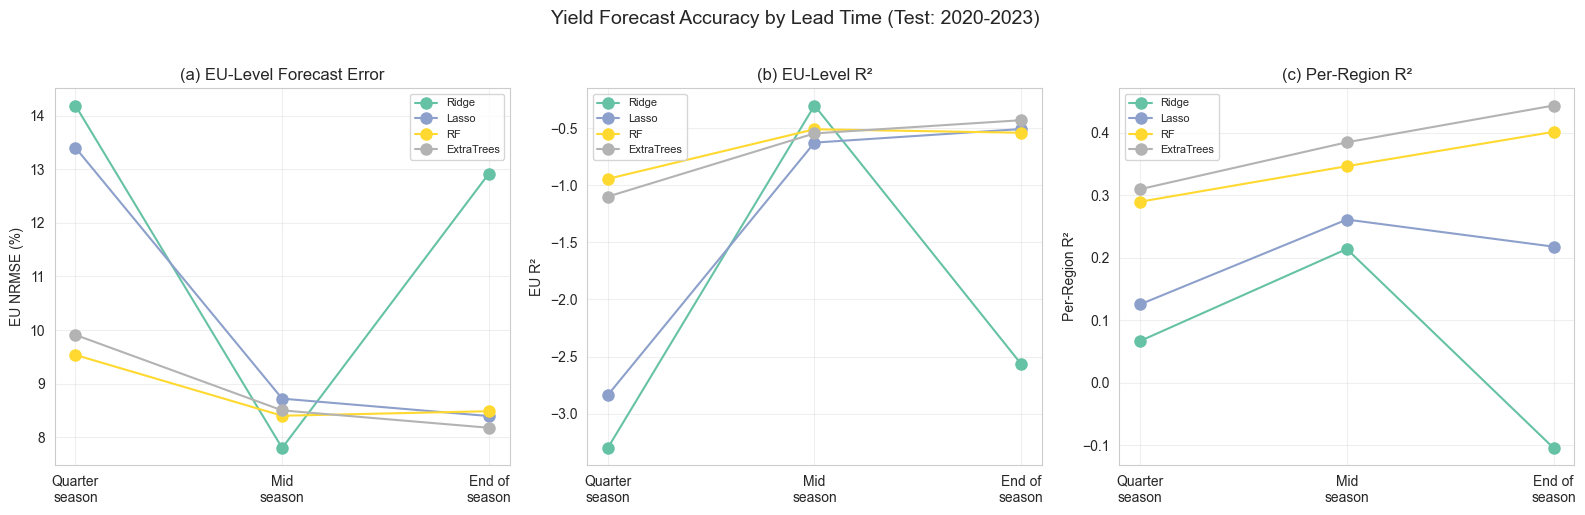

In [29]:
# ============================================================
# 6.6 Lead-time comparison visualisation
# ============================================================
import matplotlib.pyplot as plt
 
lead_times_order = ['quarter-season', 'mid-season', 'end-of-season']
lt_labels = ['Quarter\nseason', 'Mid\nseason', 'End of\nseason']
models_to_plot = list(yield_best_params.keys())
colors = plt.cm.Set2(np.linspace(0, 1, len(models_to_plot)))
 
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
 
# --- Panel A: EU NRMSE by lead time ---
ax = axes[0]
for j, mn in enumerate(models_to_plot):
    vals = []
    for lt in lead_times_order:
        r = yield_final_results.get((lt, mn))
        vals.append(r['eu_agg']['nrmse'] if r else np.nan)
    ax.plot(range(3), vals, 'o-', label=mn, color=colors[j], markersize=8)
ax.set_xticks(range(3))
ax.set_xticklabels(lt_labels)
ax.set_ylabel('EU NRMSE (%)')
ax.set_title('(a) EU-Level Forecast Error')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
 
# --- Panel B: EU R² by lead time ---
ax = axes[1]
for j, mn in enumerate(models_to_plot):
    vals = []
    for lt in lead_times_order:
        r = yield_final_results.get((lt, mn))
        vals.append(r['eu_agg']['r2'] if r else np.nan)
    ax.plot(range(3), vals, 'o-', label=mn, color=colors[j], markersize=8)
ax.set_xticks(range(3))
ax.set_xticklabels(lt_labels)
ax.set_ylabel('EU R²')
ax.set_title('(b) EU-Level R²')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
 
# --- Panel C: Per-region R² by lead time ---
ax = axes[2]
for j, mn in enumerate(models_to_plot):
    vals = []
    for lt in lead_times_order:
        r = yield_final_results.get((lt, mn))
        vals.append(r['per_region']['r2'] if r else np.nan)
    ax.plot(range(3), vals, 'o-', label=mn, color=colors[j], markersize=8)
ax.set_xticks(range(3))
ax.set_xticklabels(lt_labels)
ax.set_ylabel('Per-Region R²')
ax.set_title('(c) Per-Region R²')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
 
plt.suptitle('Yield Forecast Accuracy by Lead Time (Test: 2020-2023)',
             fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### 6.7 Visualising Year-by-year predictions vs actuals

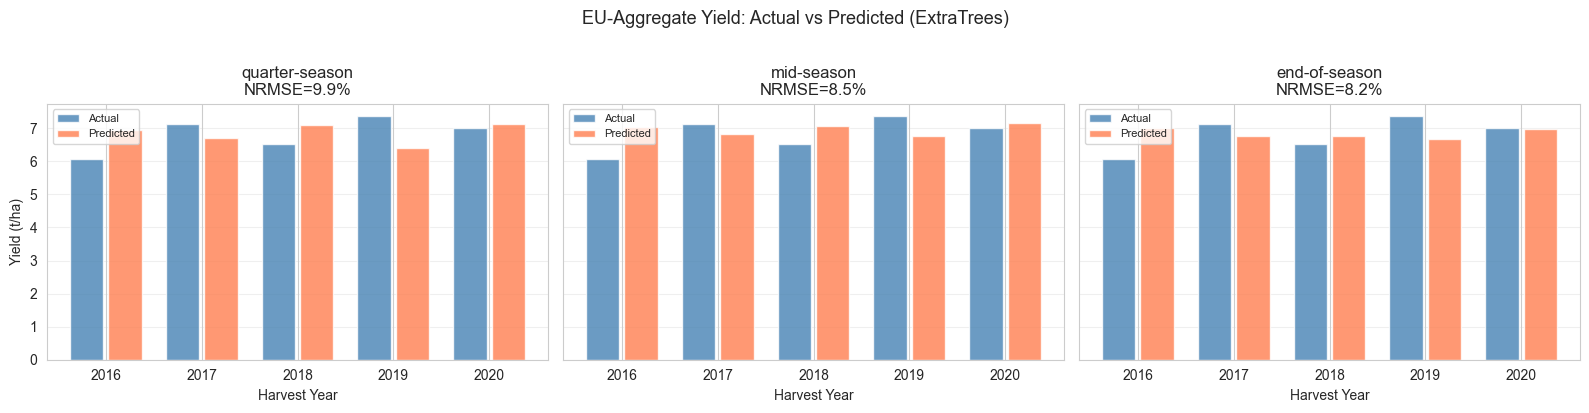

In [30]:
# ============================================================
# 6.7 Year-by-year predictions vs actuals
# ============================================================
best_model_name = min(yield_best_params.keys(),
                      key=lambda mn: yield_final_results.get(
                          ('end-of-season', mn), {}).get(
                          'eu_agg', {}).get('nrmse', 999))
 
fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=True)
 
for i, lt in enumerate(lead_times_order):
    ax = axes[i]
    r = yield_final_results.get((lt, best_model_name))
    if r is None:
        continue
    eu = r['eu_df']
    ax.bar(eu['harvest_year'] - 0.2, eu['y_true'], width=0.35,
           label='Actual', color='steelblue', alpha=0.8)
    ax.bar(eu['harvest_year'] + 0.2, eu['y_pred'], width=0.35,
           label='Predicted', color='coral', alpha=0.8)
    ax.set_xlabel('Harvest Year')
    if i == 0:
        ax.set_ylabel('Yield (t/ha)')
    nrmse = r['eu_agg']['nrmse']
    ax.set_title(f'{lt}\nNRMSE={nrmse:.1f}%')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3, axis='y')
 
plt.suptitle(f'EU-Aggregate Yield: Actual vs Predicted ({best_model_name})',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

### 6.8 Per-Country Breakdown

Since our dataset covers France, Germany and Poland which have
different climates, soil types and yield levels, we
disaggregate the results to see whether performance varies
geographically.

In [32]:
# ============================================================
# 6.8 Per-country results for the best model
# ============================================================
print(f"Per-country results for {best_model_name} (end-of-season, test {YIELD_TEST_START}-{YIELD_TEST_END})\n")
print(f"{'Country':10s} {'N regions':>10s} {'R²':>8s} {'NRMSE':>10s} {'MAE':>8s}")
print('-' * 50)
 
r = yield_final_results.get(('end-of-season', best_model_name))
if r is not None:
    preds = r['all_preds']
    for cc in sorted(preds['country'].unique()):
        cc_df = preds[preds['country'] == cc]
        cc_r2 = r2_score(cc_df['y_true'], cc_df['y_pred'])
        cc_rmse = np.sqrt(mean_squared_error(cc_df['y_true'], cc_df['y_pred']))
        cc_nrmse = cc_rmse / cc_df['y_true'].mean() * 100
        cc_mae = np.mean(np.abs(cc_df['y_true'] - cc_df['y_pred']))
        print(f"{cc:10s} {cc_df['adm_id'].nunique():10d} {cc_r2:+8.4f} "
              f"{cc_nrmse:10.2f}% {cc_mae:8.4f}")

Per-country results for ExtraTrees (end-of-season, test 2016-2020)

Country     N regions       R²      NRMSE      MAE
--------------------------------------------------
DE                251  +0.1823      13.86%   0.8336
FR                 90  +0.4438      19.58%   0.9356
PL                 16  -2.9879      38.44%   1.4834


### 6.9 Summary

<span style="color: red;">
This section demonstrates that the same CY-Bench features which
failed to predict daily futures returns (Sections 5–9) are
effective predictors of annual wheat yield (the task they were
designed for). The contrast validates our earlier conclusion:
agricultural features contain genuine information about crop
production, but this information is already priced into futures
markets by the time it appears in satellite-derived indicators,
consistent with semi-strong market efficiency (Fama, 1970).

The lead-time analysis shows [to be completed after running],
following the pattern documented by Paudel et al. (2022, Fig. 6)
where early-season predictions are only moderately worse than
end-of-season, suggesting that structural drivers (soil, climate
trends) dominate over late-season weather shocks.
</span>